# Деревья принятия решений

В тех моделях, которые мы рассматривали ранее мы чаще всего говорили о численных признаках одной природы. И проблемы могли возникать даже если эти численные признаки имели разные масштабы (мы обсуждали проблемы сходимости градиентного спуска в линейной регрессии и приходили к решению в лице метода Ньютона). Но что делать, если признаки совершенно разные? От части на этот вопрос отвечают деревья принятия решений.

Давайте начнём с того, что сгенерируем данне и построим пример решающего дерева.

In [5]:
import pandas as pd
from typing import List,Literal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor

colors = ['darkblue', 'r', 'green', "yellow"]

Сначала сгенерируем данные, как обычно, из смеси гауссиан.

In [6]:
# Генерируем центры гауссиан  для каждого класса
centers_1 = np.random.multivariate_normal([-1,-1], 1.5*np.identity(2), size=10)
centers_2 = np.random.multivariate_normal([1,1], 1.5*np.identity(2), size=10)
centers = [centers_1, centers_2]

def plot_points(ax, points, size=15, marker:Literal['o',"*"]='o', colors=['0.3', '0.3']):
    """ Функция для отрисовки нескольких наборов точек на плоскости"""
    for point, color in zip(points, colors):
        ax.scatter(point[:,0], point[:,1], s=size, marker=marker, color=color)

def sample_point(centers, cov=.1 * np.identity(2)):
    """ Генерация одной точки из смеси гауссиан """
    i = np.random.randint(len(centers))
    return np.random.multivariate_normal(centers[i], cov)

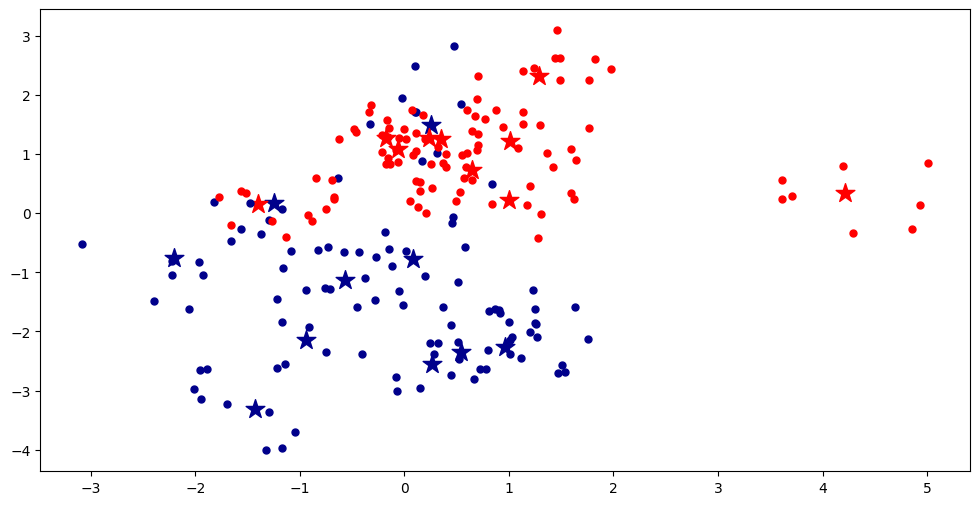

In [7]:
# Генерируем точки для кажого класса
points_1 = np.array([ sample_point(centers_1, cov=.2 * np.identity(2)) for _ in range(100) ])
points_2 = np.array([ sample_point(centers_2, cov=.2 * np.identity(2)) for _ in range(100) ])


fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plot_points(ax, points=[centers_1, centers_2], size=200, marker='*', colors=colors)
plot_points(ax, points=[points_1, points_2], size=25, marker='o', colors=colors)
# Формируем данные для обучения
X = np.concatenate([points_1, points_2], axis=0)
Y = np.concatenate([np.zeros(points_1.shape[0],dtype=np.int32), np.ones(points_2.shape[0],dtype=np.int32)])

In [8]:
import pydotplus
from IPython.display import Image, display

def plot_tree(clf):
    """ Функция для отрисовки обученного дерева. """
    dot_data = export_graphviz(clf, out_file=None, 
                             filled=True, rounded=True,  
                             special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data)  
    display(Image(graph.create_png()))

In [9]:
def plot_classifier(clf, data_X, plot_step=0.01, use_xgboost=False):
    """ Отрисовка разделяющей поверхности классификатора"""
    x_min, x_max = data_X[:, 0].min() - 1, data_X[:, 0].max() + 1
    y_min, y_max = data_X[:, 1].min() - 1, data_X[:, 1].max() + 1
    # Формируем решётку 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    # Получаем предсказания по решётке
    data_to_predict = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(data_to_predict)
    if use_xgboost:
        Z = (Z > 0.5).astype(int)
    # Рисуем heatmap по решётке
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.5) # plt.cm.bwr

def plot_classifier_with_points(clf, X, Y, centers, use_xgboost=False):
    """ Функция для рисования точек и разделяющей поверхности классификатора """
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    plot_classifier(clf, X, use_xgboost=use_xgboost)
    size = len(centers)
    plot_points(ax, centers, size=150, marker='*', colors=colors)
    y_uniq = np.unique(Y)
    points = []
    for uniq in y_uniq:
        points.append(X[Y == uniq])
    plot_points(ax, points, size=15, marker='o', colors=colors)
    plt.axis("tight")
    plt.show()

Наконец обучим небольшое дерево принятия решений и отобразим его.

Дерево принятия решений состоит из узлов, в каждом из которых записано простое логическое условие, касающееся одной из компонент вектора $\overline{x}$. 

Чтобы получить предсказание нам необходимо начать с корня, проверить выполнение описанного в узле условия, далее необходимо перейти в соответствующего сына узла. Так процедура повторяется рекурсивно, пока мы не дойдём до листа. В листе дерева отмечено то, к какому классу будет принадлежать точка данных.

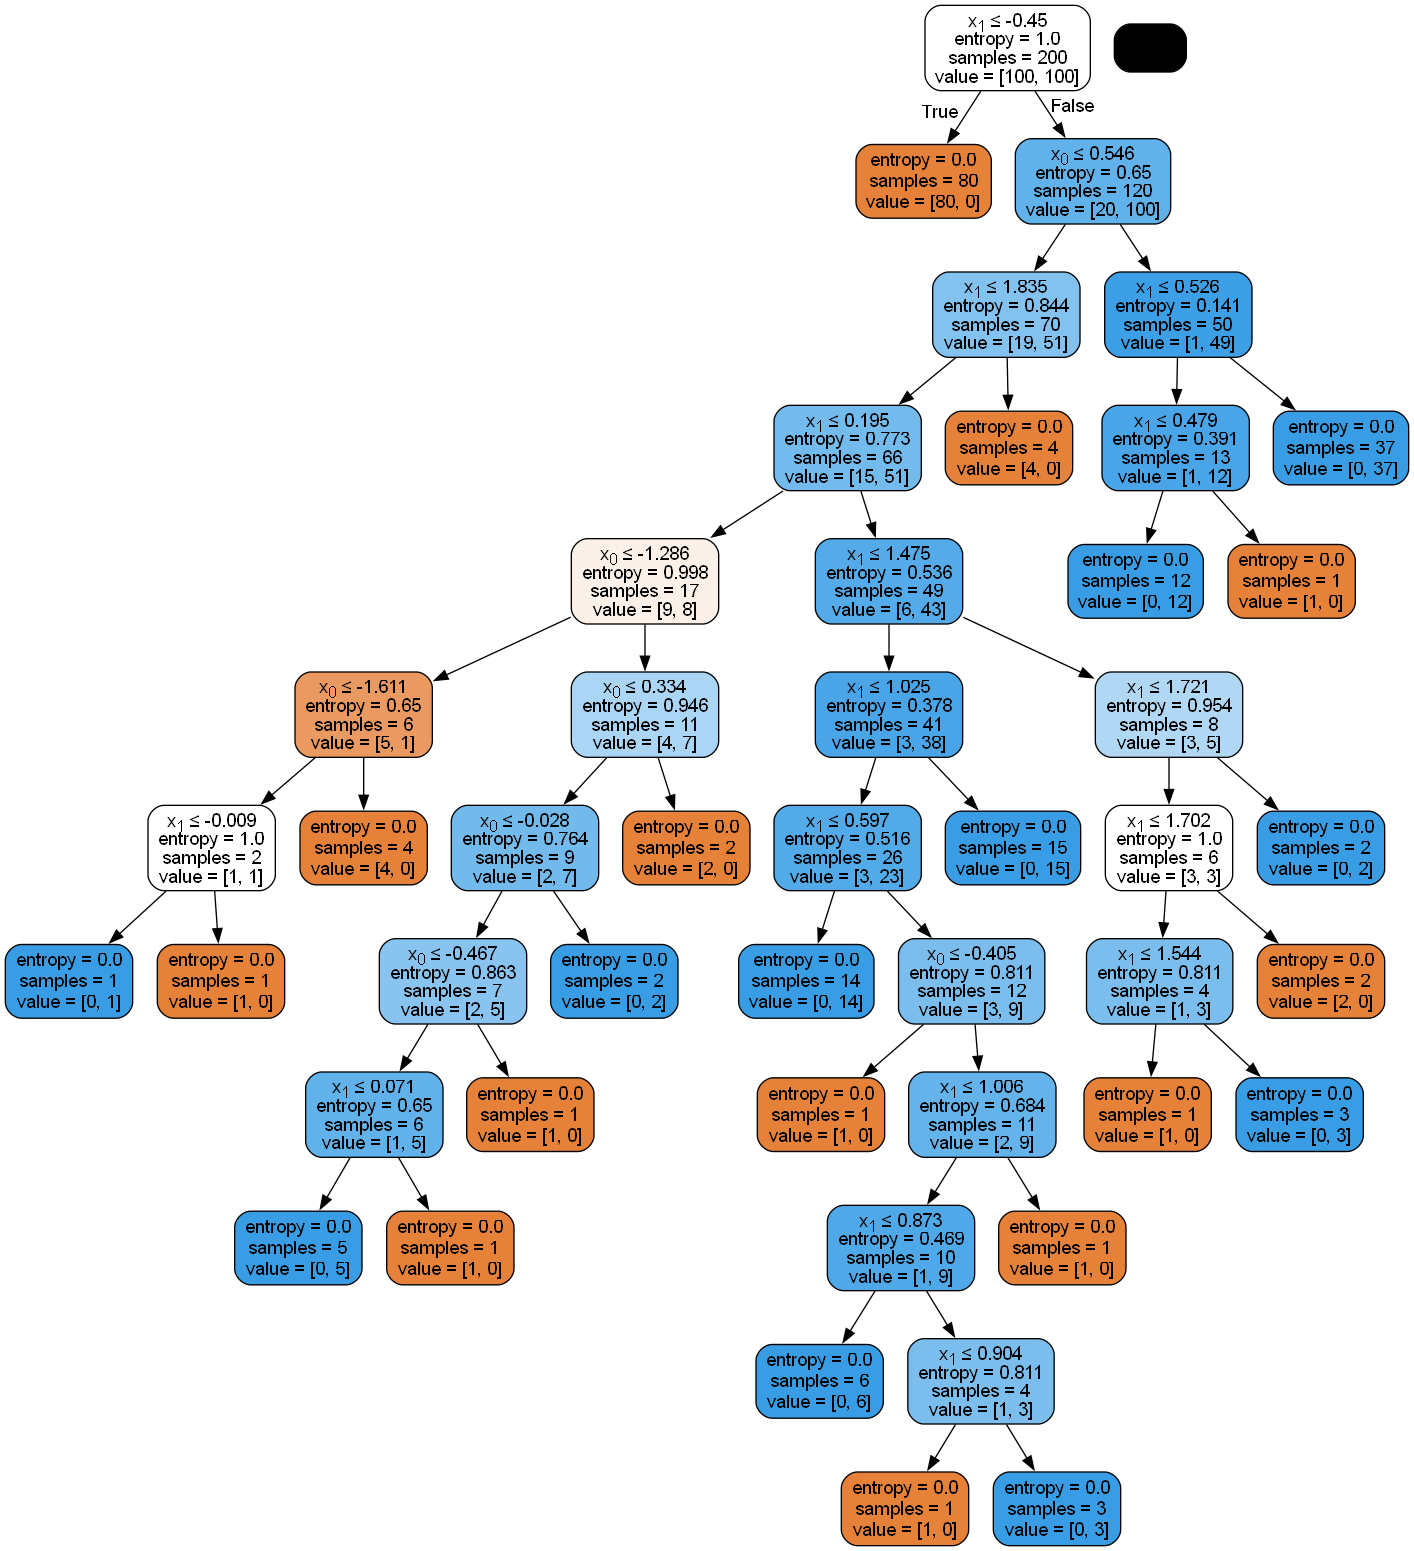

In [10]:
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X, Y)

plot_tree(model)

Если отобразить разделяющую поверхность, получаемую решающим деревом, мы увидим область пространства, отделённую прямыми, параллельными оси координат.

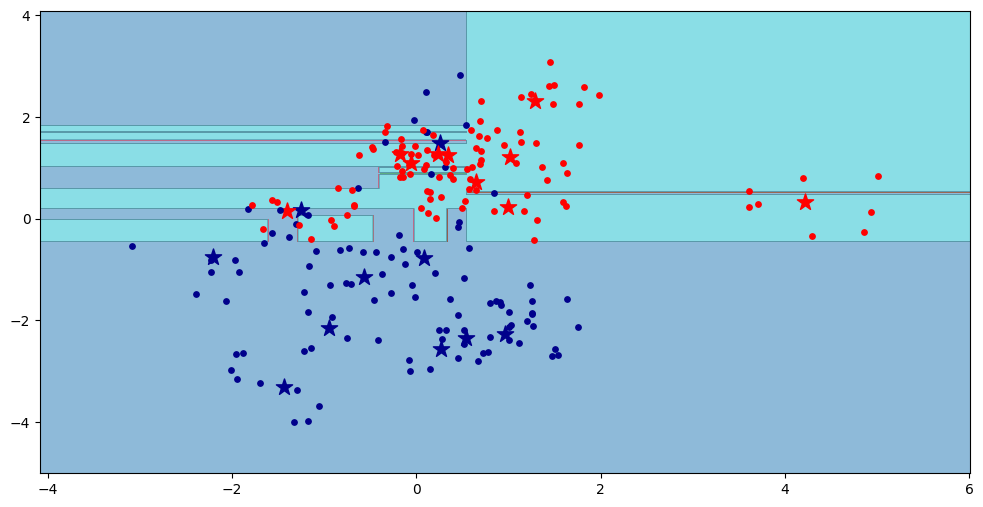

In [11]:
plot_classifier_with_points(model, X,Y, centers)

## Обучение деревьев принятия решения

Мы решаем задачу обучения с учителем $D=\{(\overline{x}_n,y_n)\}_{n=1}^N$. При обучении дерева нам необходимо:

1) Выбрать признак $x_i$.
2) Выполнить разбиение по признаку $x_i<a$.
3) Все $\overline{x}_n\in D$, для которых $x_{ni}<a$ поместить в левое поддерево, а все остальные точки – в правое поддерево.


Необходимо определить то, как мы будем формировать эти разбиения и как будем выбирать признак, по которому делать разбиение.

Пока остановимся на задаче классификации. Мы бы хотели, чтобы распределение точек в листах было не случайным, то есть не похожим на равномерное распределение. Получается, что мы хотим максимизировать KL-конвергенцию с равномерным распределением, то есть минимизировать **энтропию**.

Энтропия вычисляется по формуле: $$H(D)=-\sum_np_n\ln p_n,$$ где $p_n$ это доля точек, принадлежащих классу $n$, содержащихся в узле $D$.

В качестве функции ошибки используют **количество информации** (Information Gain):

$$Gain(D,x_i)=H(D)-\sum_n\frac{|D_n|}{|D|}H(D_n).$$

$D$ - множество точек в узле, который мы разбиваем. $D_n$ - множества, получаемые после разбиения.

Для ускорения вычислений и избежания численных проблем, связанных с использованием логарифма, часто энтропию заменяют на **индекс Джини**:

$$Gini = \frac{1}{n}\sum_n(p_n(1-p_n)).$$

Далее имея целевую функцию необходимо определить как мы будем получать разбиения. Для этого можно использовать следующий жадный алгоритм:

- Среди признаков выбираем тот, который будет порождать разбиение с наибольшей информацией.

- Для каждого признака переберём в качестве кандидатов на разбиения средние между соседними значениями в отсортированном массиве. 

- Выбираем признак и разбиение, которые дают наибольшую информацию.

Стоит отметить, что жадный алгоритм не обязательно построит оптимальное дерево, но зато обучение можно вести параллельно.

Вычислительная сложность алгоритма, применяемого в sci-kit learn $O(\#\{\text{признаков}\}\cdot\#\{\text{данных}\}\cdot \text{глубина дерева})$. Достигается это за счёт хитрого кеширования и отслеживания порядка элементов при разбиении, так что необходимость в постоянной сортировке значений отпадает.

Важно отметить, что в общем случае решающие деревья допускают обработку категориальных признаков без дополнительных преобразований. Для этого, к примеру, можно произвести разбиение узла с образованием наследников для каждой имеющейся категории, правда такой метод при большом количестве категорий скорее всего приведёт к переобучению. Поэтому необходимо делать что-то более умное. К сожалению, в sci-kit learn на нынешний момент нет поддержки обработки категориальных признаков в деревьях принятия решений, но другие библиотеки могут их поддерживать, с некоторыми мы познакомимся, когда будем проходить ансамбли моделей.

Зато решающие деревья могут корректно обрабатывать пропуски в данных. 
- Важно отметить, что если пропуски можно как-то "по-умному" заполнить, то лучше это сделать. Не стоит полагаться на то, что решающие деревья решат эту проблему за вас. 
- Если же хорошего решения не нашлось и ваше решение проблемы пропусков $-$ заполнение средним/медианой/нулём и т.д., то в таком случае лучше довериться решающим деревьям.

Параметр `criterion` как раз отвечает за то, какая целевая функция используется. Заметим, что для тех же самых данных мы получили другое решение. Связано это с тем, что хотя точки минимума и у энтропии и у индекса Джини совпадают,формы их функций (а значит, и поверхность оптимизации) различаются, что и приводит к отличиям в результате обучения.

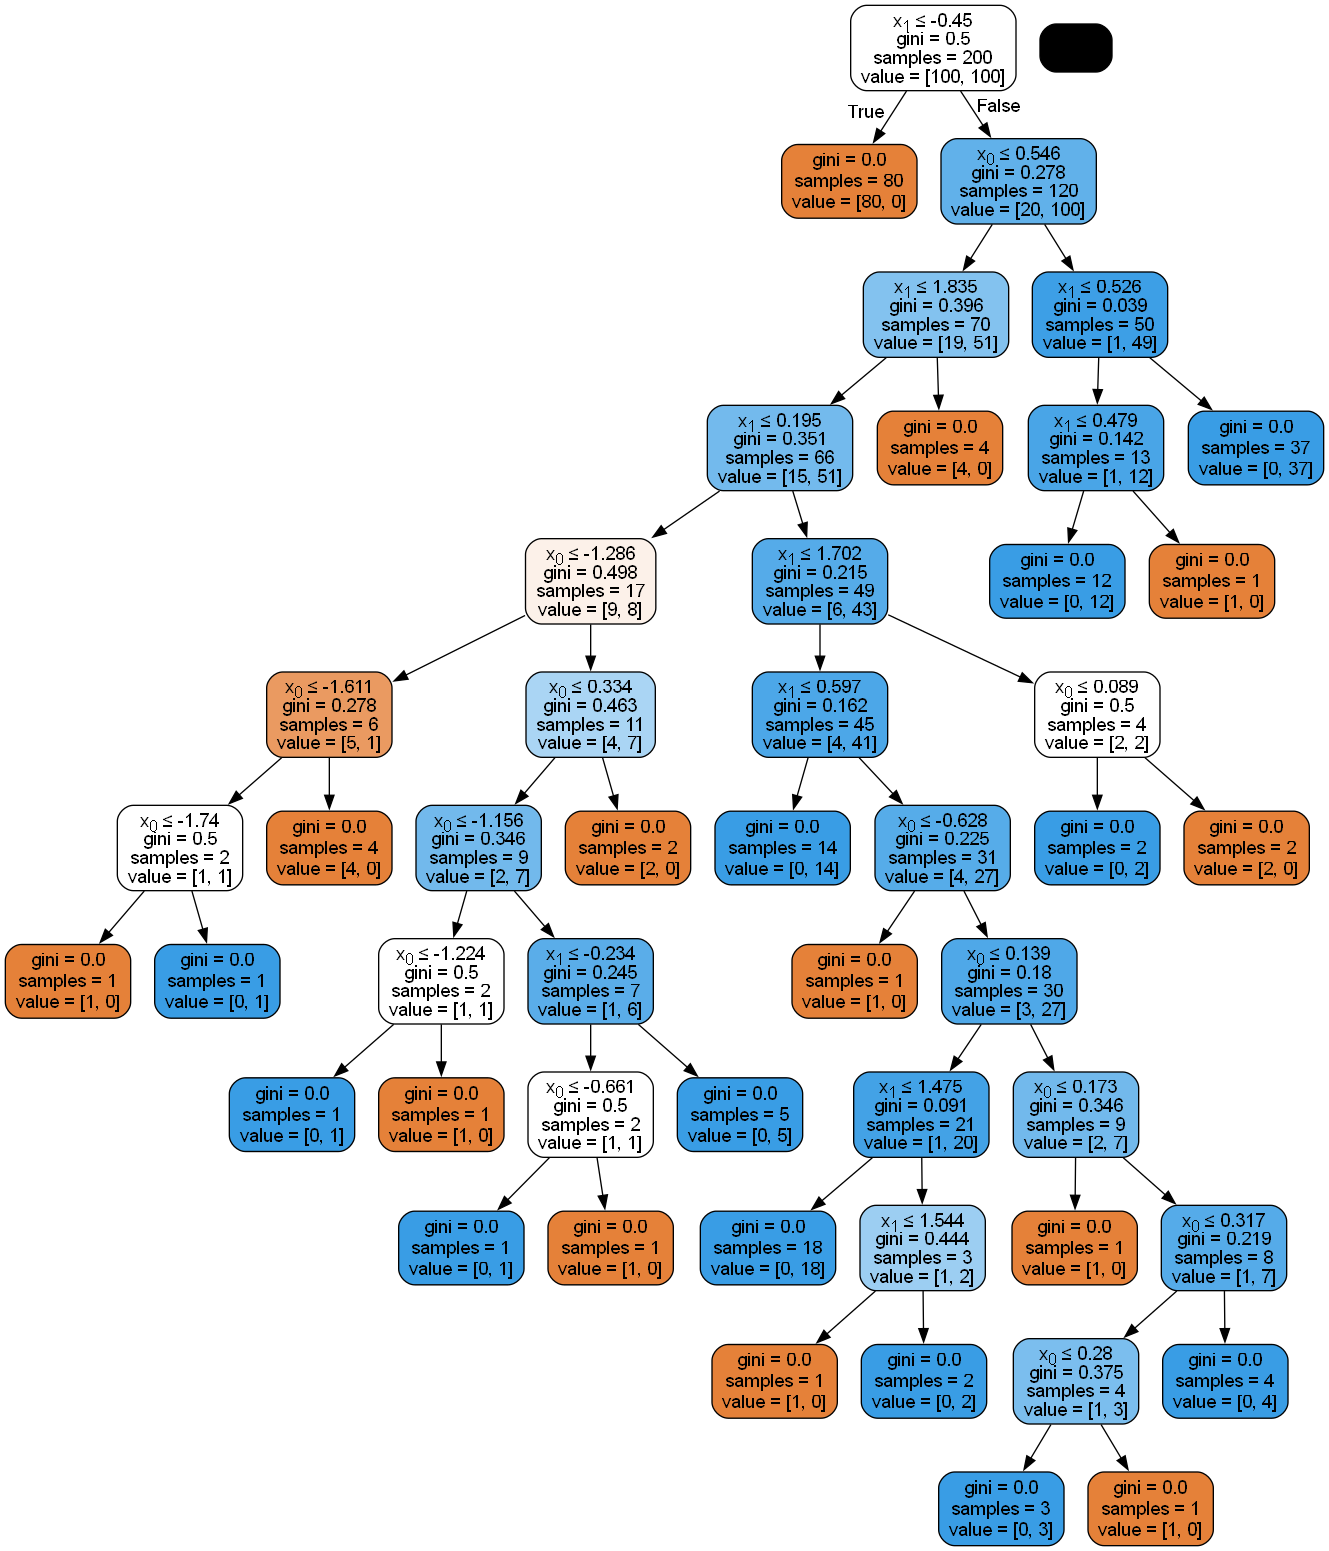

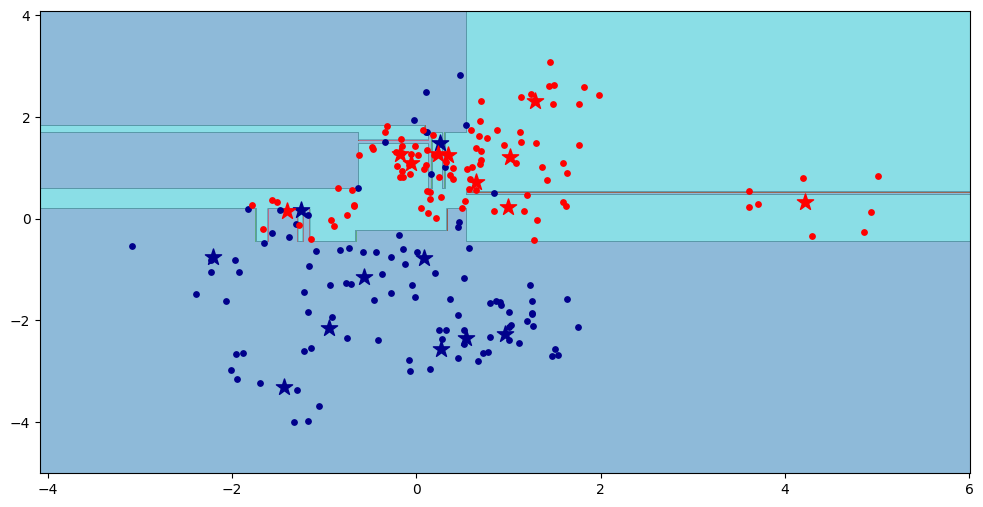

In [12]:
model = DecisionTreeClassifier(criterion="gini")
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, centers)

## Методы регуляризации

Деревья принятия решений могут переобучаться на обучающей выборке, вплоть до запоминания всей выборки. Чтобы бороться с переобучением деревьев, необходимо скоректировать параметры регуляризации.

Мы можем регулировать следующие параметры у дерева:
* *max_depth* $-$ максимальная глубина дерева. При слишком большой глубине в листьях дерева собираются 1-5 точек и разделяющая поверхность классов начинает концентироваться в отдельных точках.
* *min_samples_split* $-$ минимальное количество образцов для разделения узла. Чем выше данный параметр, тем меньше количество точек будут обосабливаться классификатором. По умолчанию равен 2, то есть если в узле содержатся всего 2 образца, то произойдёт разделение узла на 2 листа с изолированными точками.
* *min_samples_leaf* $-$ минимальное количество образцов в листе. Чем меньше, тем большее количество малых скоплений точек будет создавать классификатор.
* *max_leaf_nodes* $-$ максимальное количество листьев.

Предыдущие параметры влияют на алгоритм расщепления узлов, ограничивая рост дерева. А следующий параметр подходит к регуляризации с другой стороны, он отвечает на вопрос о том, как обрезать переобученное дерево с минимальными потерями в качестве классификации.

* *ccp_alpha* $-$ параметр обрезки (Cost Complexity Pruning). По умолчанию равен 0, то есть обрезка дерева не производится.

Параметры регуляризации можно подбирать эмпирически или с помощью кросс-валидации, это мы попробуем сделать чуть позже.

Теперь поговорим о том, как происходит обрезка дерева с помощью алгоритма минимальной стоимости-сложности (CCP). Данный алгоритм минимизирует функцию ошибки
$$R_{\alpha}(T) = R(T) + \alpha \cdot |T|, $$
где $R(T) -$ ошибка классификации дерева (например, доля правильных ответов accuracy), $|T| -$ количество листьев, $\alpha -$ параметр, при увеличении которого алгоритм будет обрезать больше листьев. Этот параметр обеспечивает баланс между ошибкой дерева (стоимостью) и его сложностью (размером по количеству узлов).

Для каждого нелистового узла вычисляется "эффективность" обрезки:
$$g(t)=\frac{R(t) - R(T_t)}{|T_t|-1}, $$
где $R(t) -$ ошибка узла $t$, если его сделать листом, $R(T_t) -$ ошибка поддерева $T_t$ с корнем в $t$.

Узел с наименьшим значением эффективности $g(t)$ становится листом, а всё, связанное с ним поддерево, обрезается. Минимум $g(t)$ означает, что удаление поддерева $T_t$ даёт наименьшее ухудшение ошибки классификации. Процесс обрезки прекращается, когда минимальное значение $g(t)$ становится больше параметра $\alpha$.

Давайте попробуем применять разные способы регуляризации.

Сначала ограничим глубину дерева.

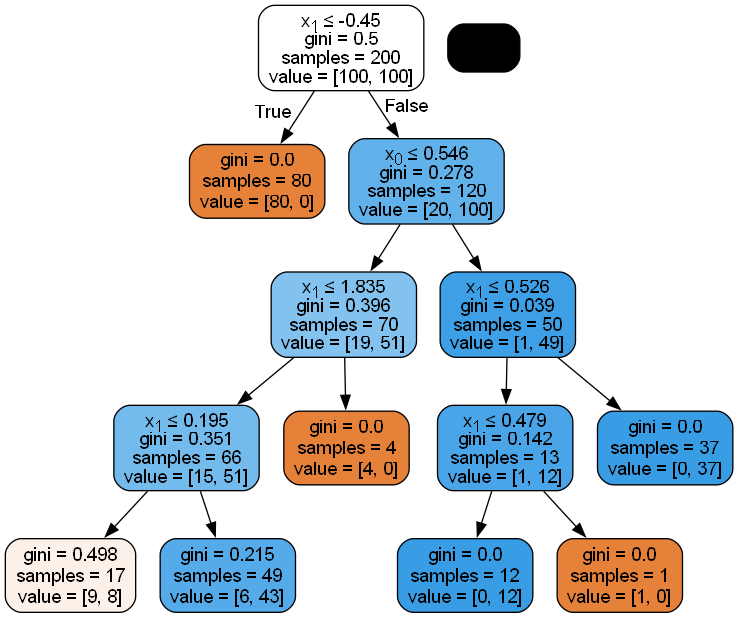

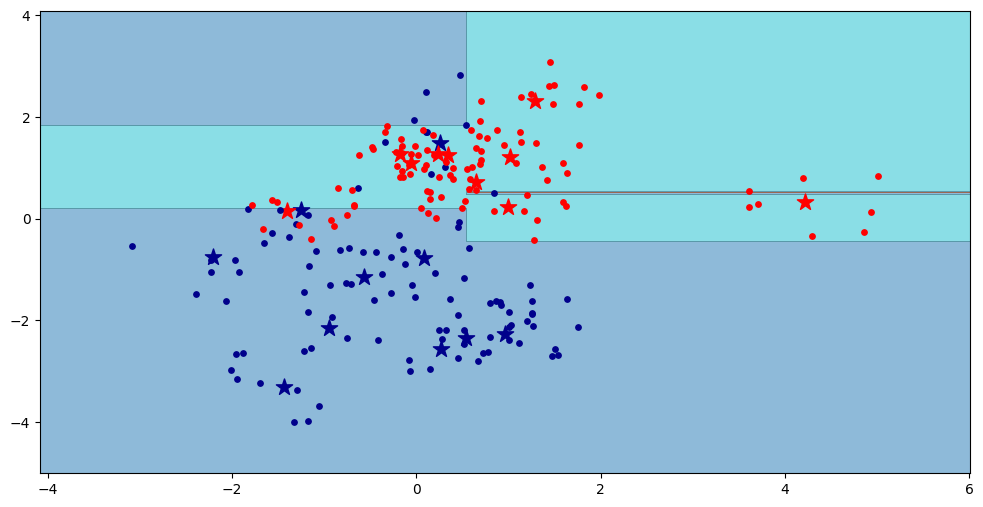

In [13]:
model = DecisionTreeClassifier(max_depth=4)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

Ограничим количество листьев.

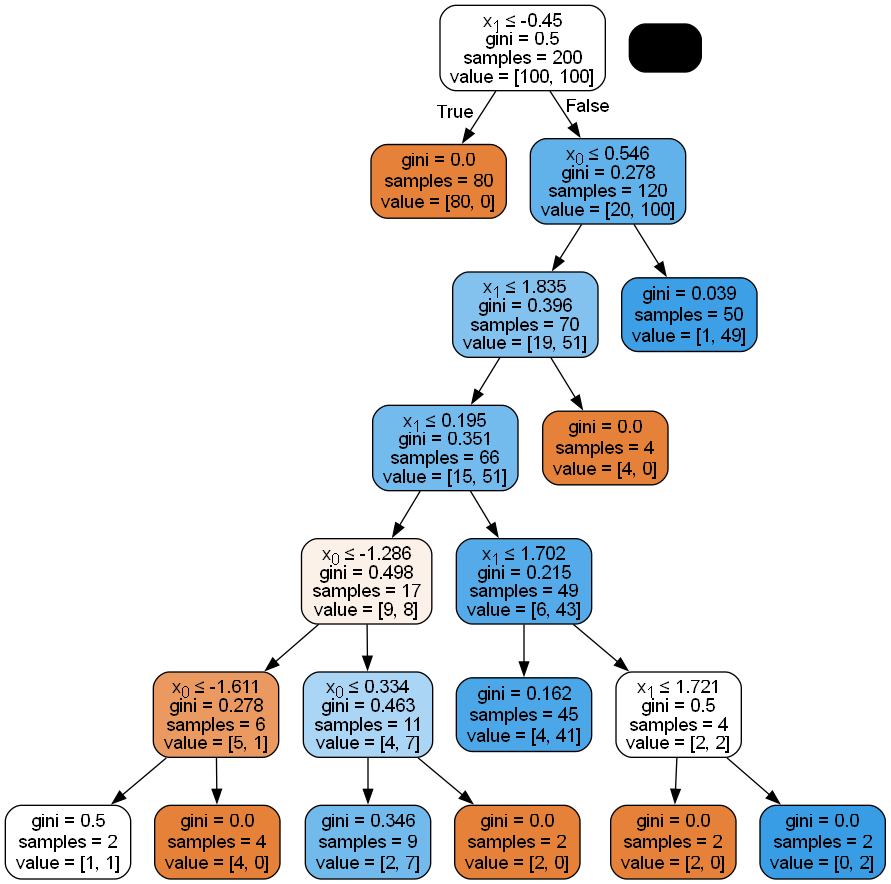

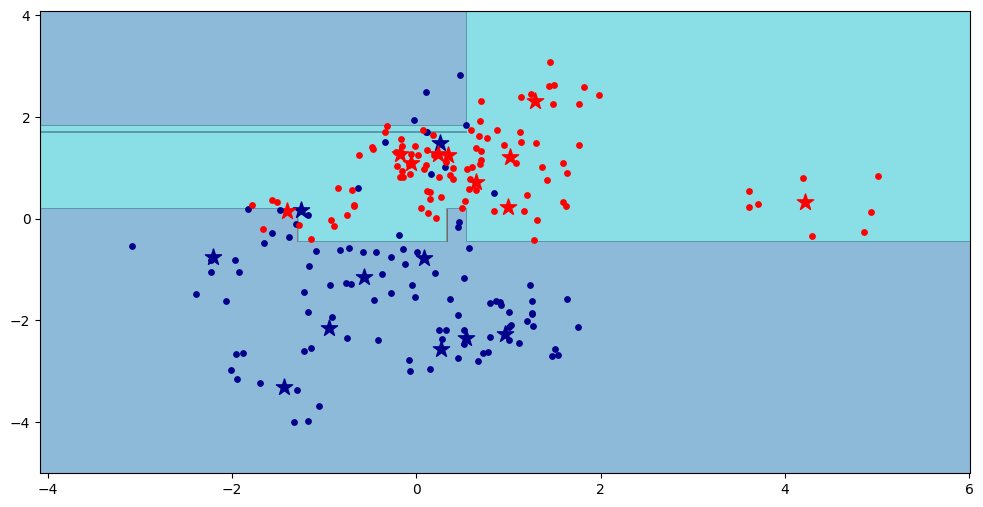

In [14]:
model = DecisionTreeClassifier(max_leaf_nodes=10)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

Ограничим количество точек для образования разбиения.

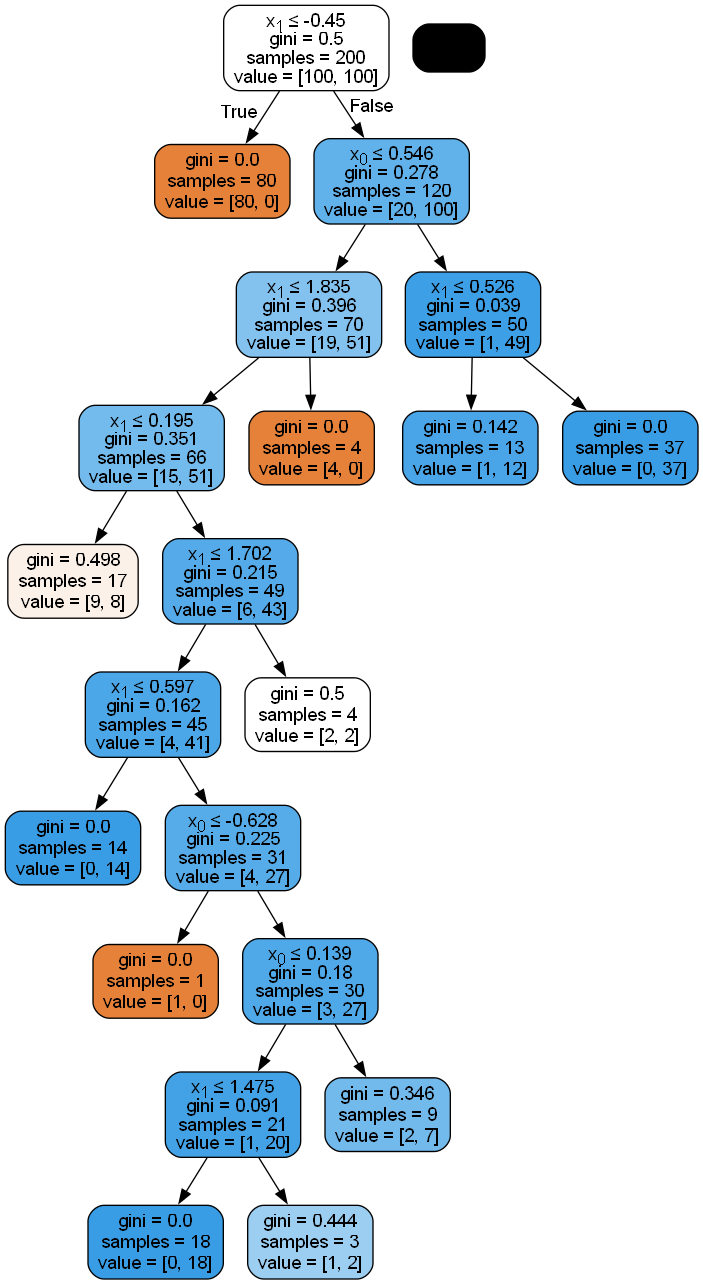

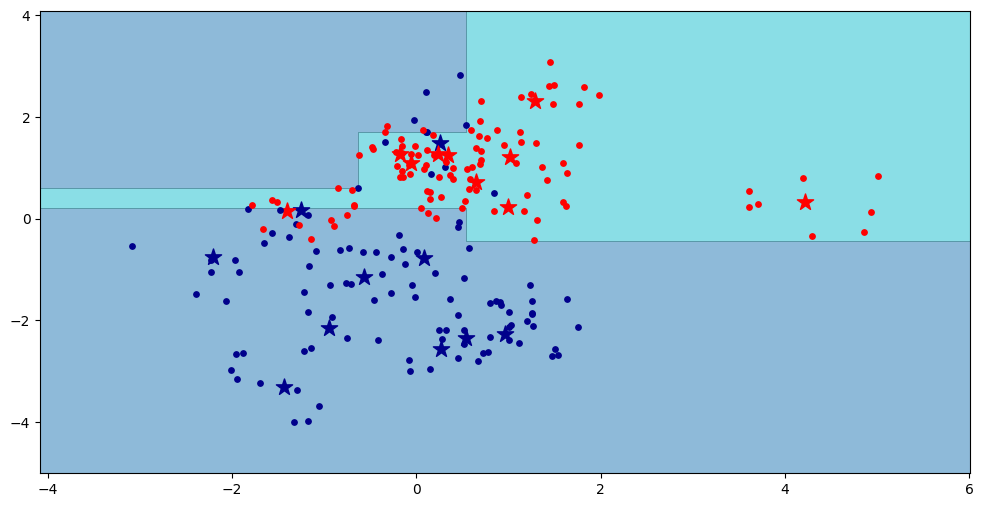

In [15]:
model = DecisionTreeClassifier(min_samples_split=20)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

Ограничим количество точек данных в листьях. Можно заметить, что довольно большая часть дерева не выполняет никакой полезной нагрузки. Вызвано это тем, что в некоторых узлах содержится некоторое количество ложно классифицируемых объектов, но их недостаточно, чтобы отделить их в лист. Чтобы это исправить необходимо добавить обрезку дерева.

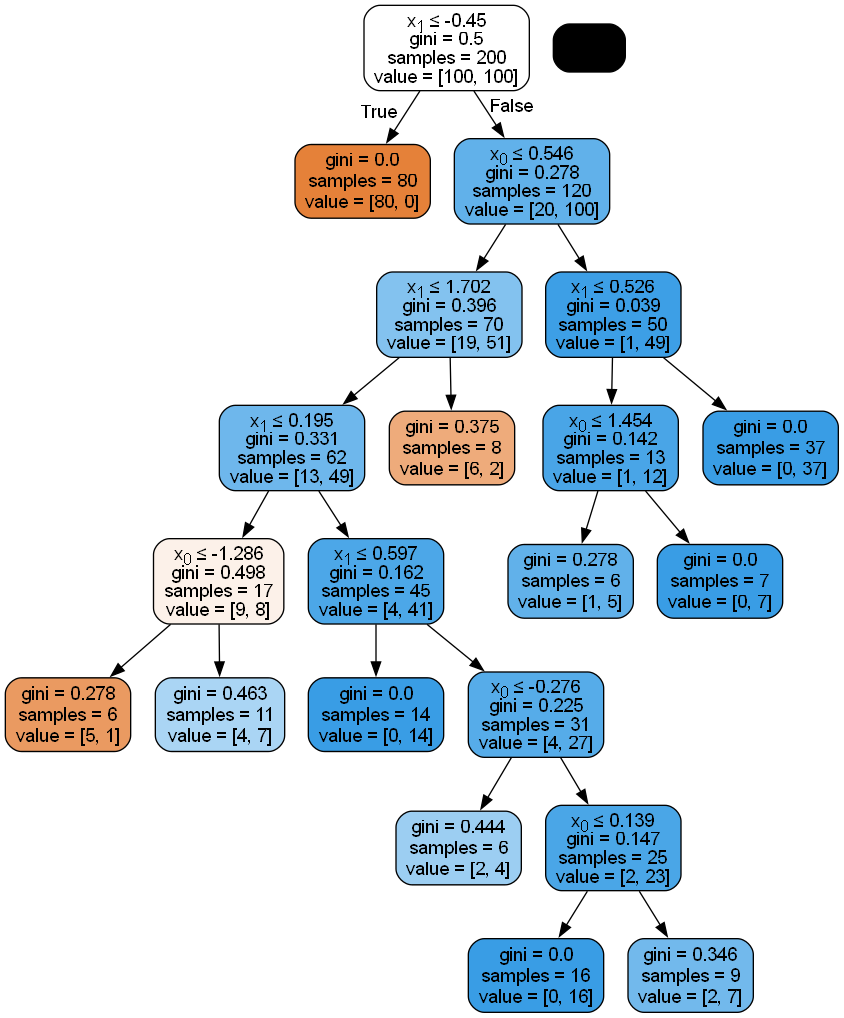

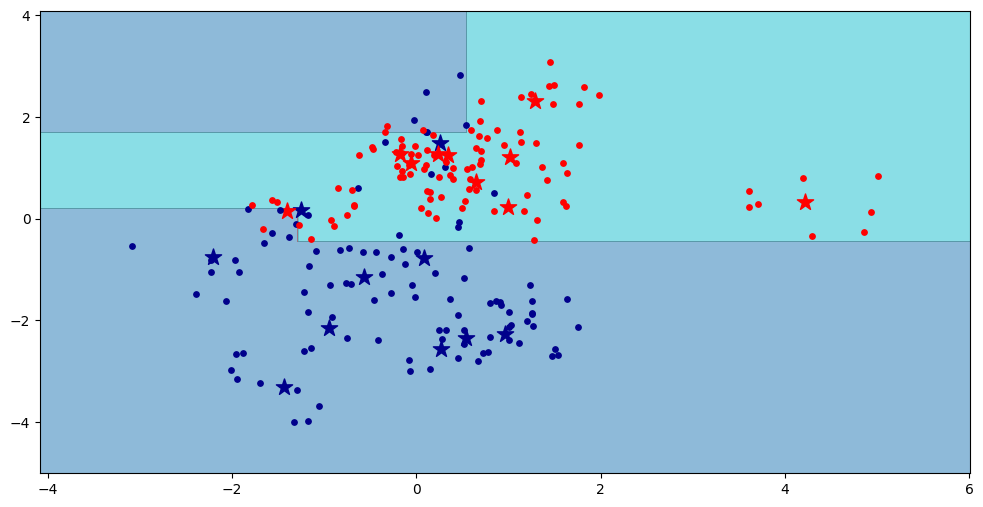

In [16]:
model = DecisionTreeClassifier(min_samples_leaf=6)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

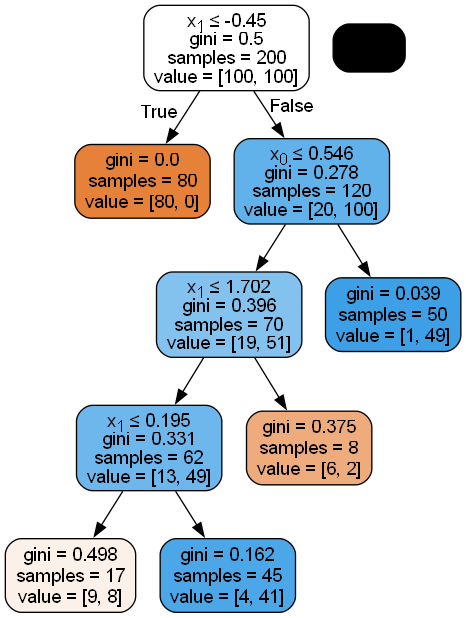

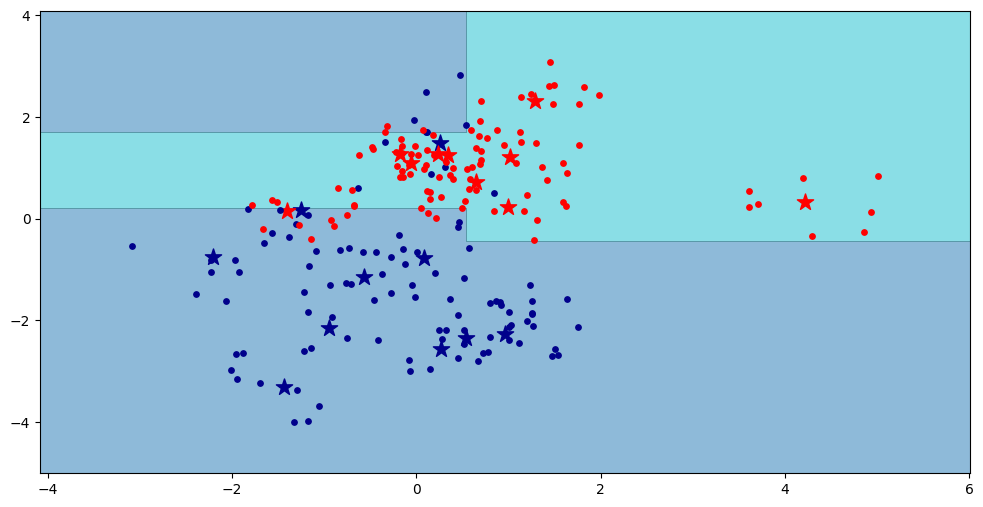

In [17]:
model = DecisionTreeClassifier(min_samples_leaf=6, ccp_alpha=0.01)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

Также применим только обрезку деревьев:

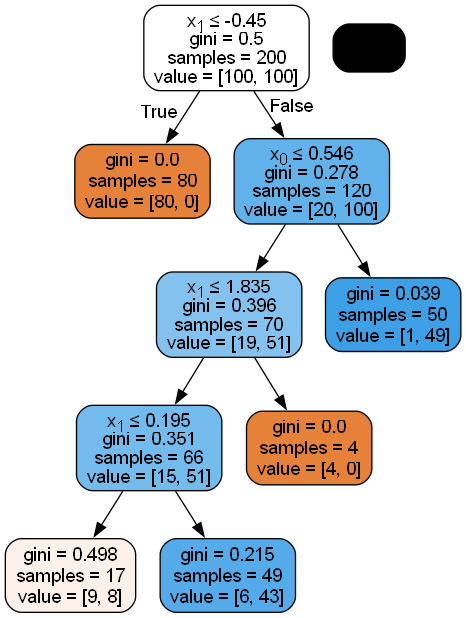

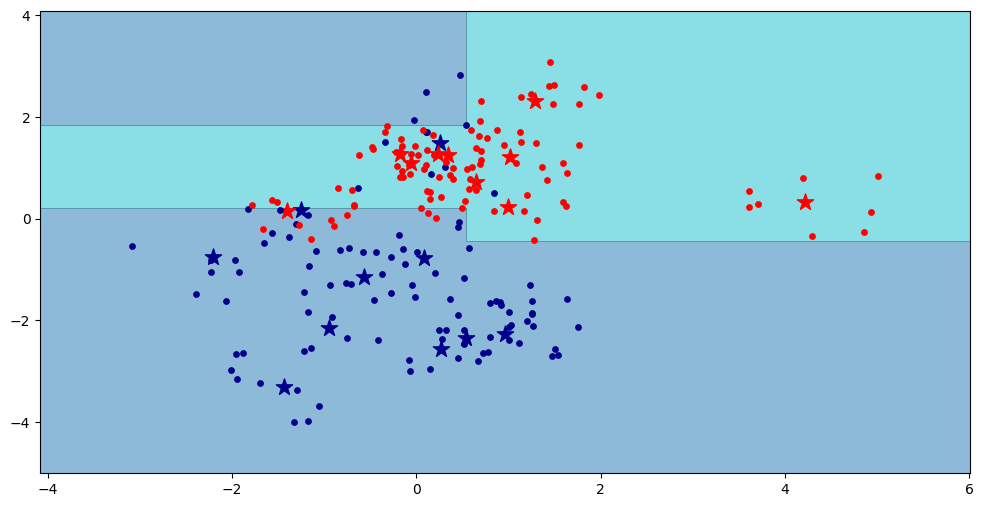

In [18]:
model = DecisionTreeClassifier(ccp_alpha=0.01)
model.fit(X, Y)

plot_tree(model)
plot_classifier_with_points(model, X,Y, [centers_1,centers_2])

## Обучение гиперпараметров

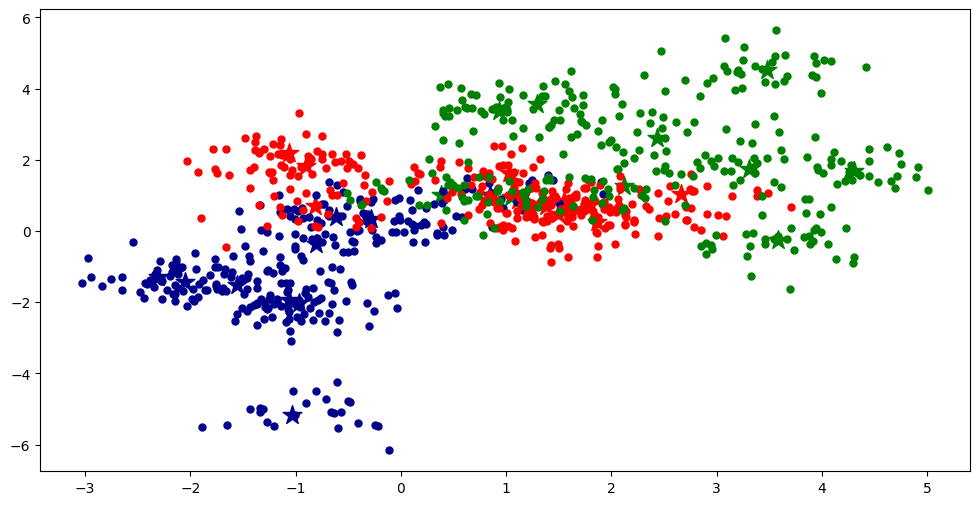

In [19]:
centers_1 = np.random.multivariate_normal([-1,-1], 1.5*np.identity(2), size=10)
centers_2 = np.random.multivariate_normal([1,1], 1.5*np.identity(2), size=10)
centers_3 = np.random.multivariate_normal([3,2], 1.5*np.identity(2), size=10)
centers = [centers_1, centers_2, centers_3]

# Генерируем точки для кажого класса
points_1 = np.array([ sample_point(centers_1, cov=.2 * np.identity(2)) for _ in range(300) ])
points_2 = np.array([ sample_point(centers_2, cov=.2 * np.identity(2)) for _ in range(300) ])
points_3 = np.array([ sample_point(centers_3, cov=.2 * np.identity(2)) for _ in range(300) ])


fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plot_points(ax, points=centers, size=200, marker='*', colors=colors)
plot_points(ax, points=[points_1, points_2, points_3], size=25, marker='o', colors=colors)
# Формируем данные для обучения
X = np.concatenate([points_1, points_2, points_3], axis=0)
Y = np.concatenate([np.zeros(points_1.shape[0],dtype=np.int32), 
                    np.ones(points_2.shape[0],dtype=np.int32),
                    2 * np.ones(points_3.shape[0],dtype=np.int32)])

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

Сразу важно отметить, что многие параметры напрямую зависят от количества данных в выборке, поэтому их никогда нельзя угадать оптимально. С решающими деревьями всегда необходимо проводить поиск гиперпараметров с кросс-валидацией.

Я всё же попробую угадать параметры:

Accuracy на тестовой выборке:  0.8611111111111112


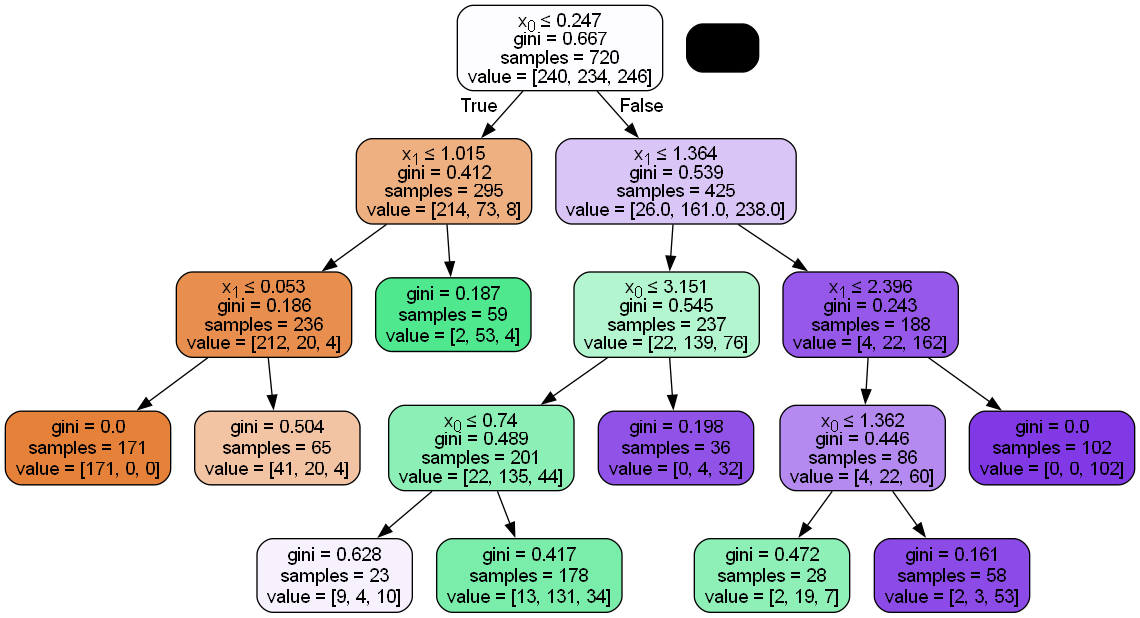

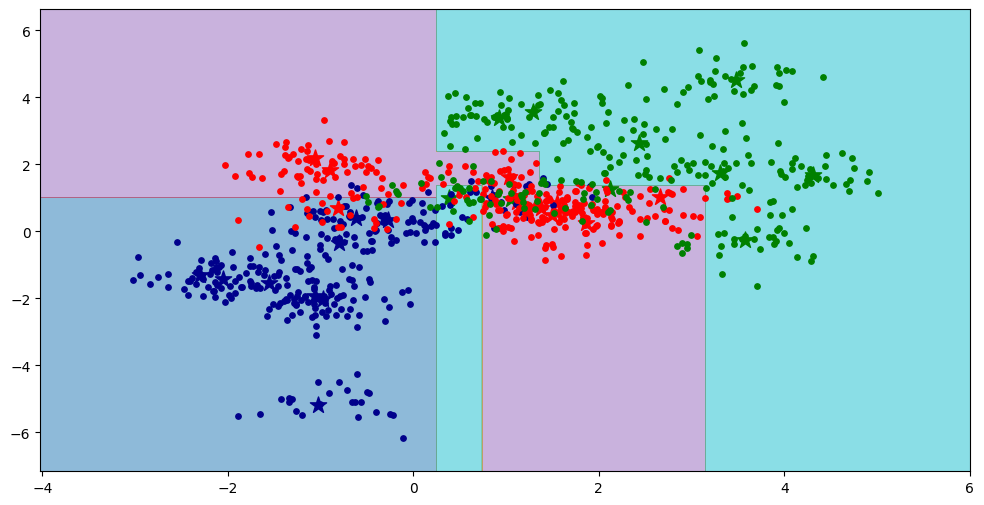

In [21]:
model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=6, min_samples_split=10, max_leaf_nodes=20, ccp_alpha=0.01)

model.fit(X_train, Y_train)

print("Accuracy на тестовой выборке: ", model.score(X_test, Y_test))
plot_tree(model)
plot_classifier_with_points(model, X, Y, [centers_1,centers_2, centers_3])

А теперь воспользуемся кросс-валидацией.

In [22]:
from sklearn.model_selection import GridSearchCV

# задаём сетку параметров
param_grid ={
    "max_depth": [None, 5, 10, 20, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "ccp_alpha": [0.0, 1e-3, 1e-2, 1e-1, 5e-1, 1]
}
model = DecisionTreeClassifier()
gs = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)

gs.fit(X_train, Y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0, 0.001, ...], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [23]:
gs.best_params_

{'ccp_alpha': 0.001,
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Accuracy на тестовой выборке:  0.7833333333333333


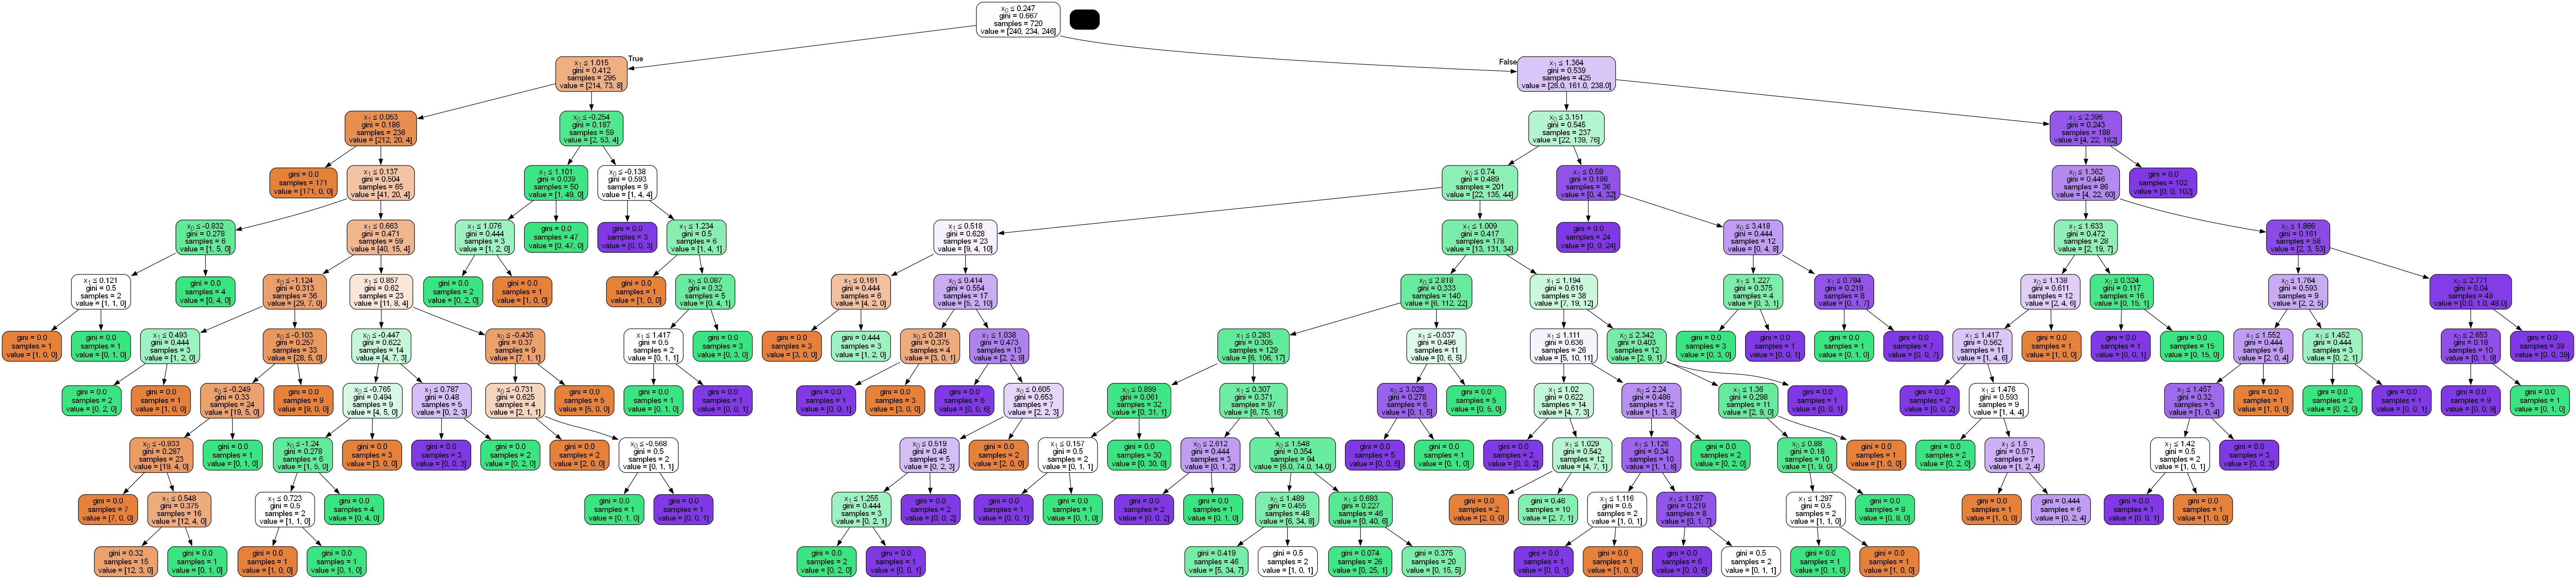

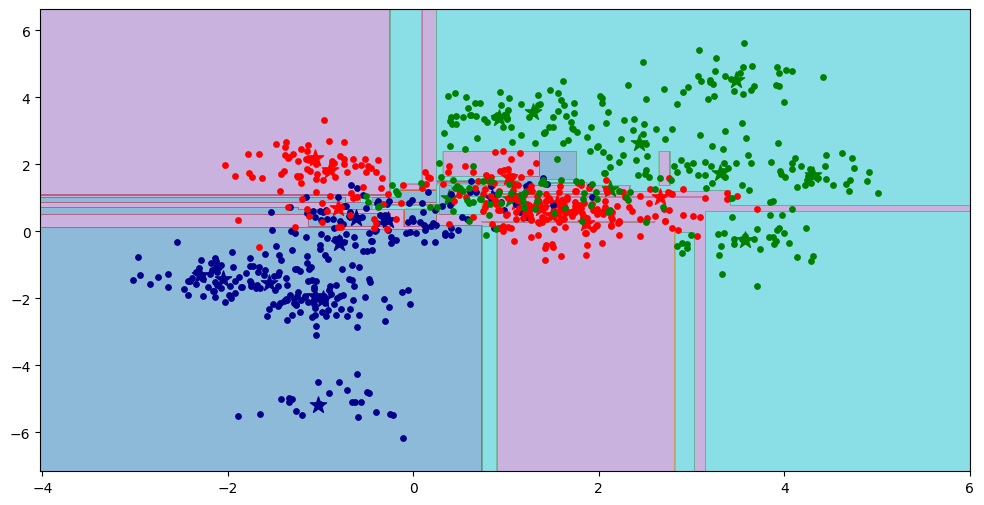

In [24]:
model = gs.best_estimator_
print("Accuracy на тестовой выборке: ", model.score(X_test, Y_test))
plot_tree(model)
plot_classifier_with_points(model, X, Y, [centers_1,centers_2, centers_3])

Также можно задавать поиск не по заранее известной сетке, а генерировать параметры из распределения. Считается, что при одинаковых вычислительных ресурсах `RandomizedSearchCV` работает не хуже чем `GridSearchCV`, но позволяет перебирать не все возможные комбинации параметров, на чём можно сэкономить время.
 
Для параметра `ccp_alpha` нас интересует не его конкретное значение, а его масштаб, поэтому логично взять loguniform распределение.

Функция плотности этого распределения выглядит: 

$$f(x,a,b)=\frac{1}{x\log{\frac{b}{a}}},$$

для $x\in[a,b]$, $b>a>0$. Если извлечь из значений логарифм, то мы получим равномерное распределение.

Text(0.5, 1.0, 'Гистограмма логарифмов значений')

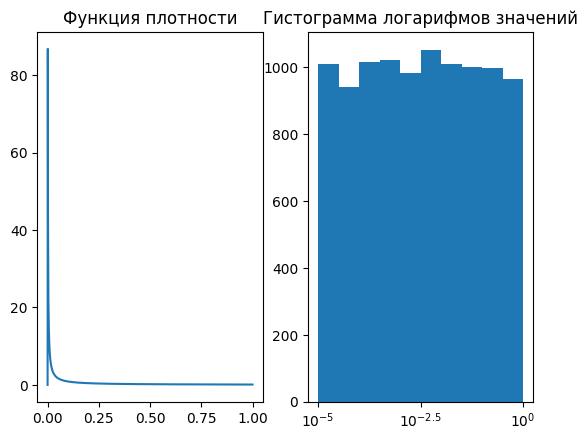

In [25]:
from scipy.stats import loguniform

distr = loguniform(1e-5,1)
fig,axes = plt.subplots(1,2)
x = np.linspace(0,1, 1000)
axes[0].plot(x, distr.pdf(x))
axes[0].set_title("Функция плотности")
samples = distr.rvs(10000)
axes[1].hist(np.log10(samples))
axes[1].xaxis.set_major_locator(plt.FixedLocator([-5, -2.5, 0]))
ticks = ["$10^{{ {} }}$".format(i) for i in [-5, -2.5, 0]]
axes[1].set_xticklabels(ticks)  
axes[1].set_title("Гистограмма логарифмов значений")

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# Задаём распределения на параметры
param_dist = {
    "max_depth": randint(3, 60),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 30),
    "ccp_alpha": loguniform(1e-9, 0.1)
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=6000,
                        cv=5, scoring="accuracy", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train, Y_train)


Fitting 5 folds for each of 6000 candidates, totalling 30000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC... max_depth=10)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'ccp_alpha': <scipy.stats....001FF1930CF50>, 'max_depth': <scipy.stats....001FF17D5D160>, 'min_samples_leaf': <scipy.stats....001FF1930D090>, 'min_samples_split': <scipy.stats....001FF1930C410>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide 

In [27]:
rs.best_params_

{'ccp_alpha': np.float64(1.6496518193924311e-09),
 'max_depth': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 5}

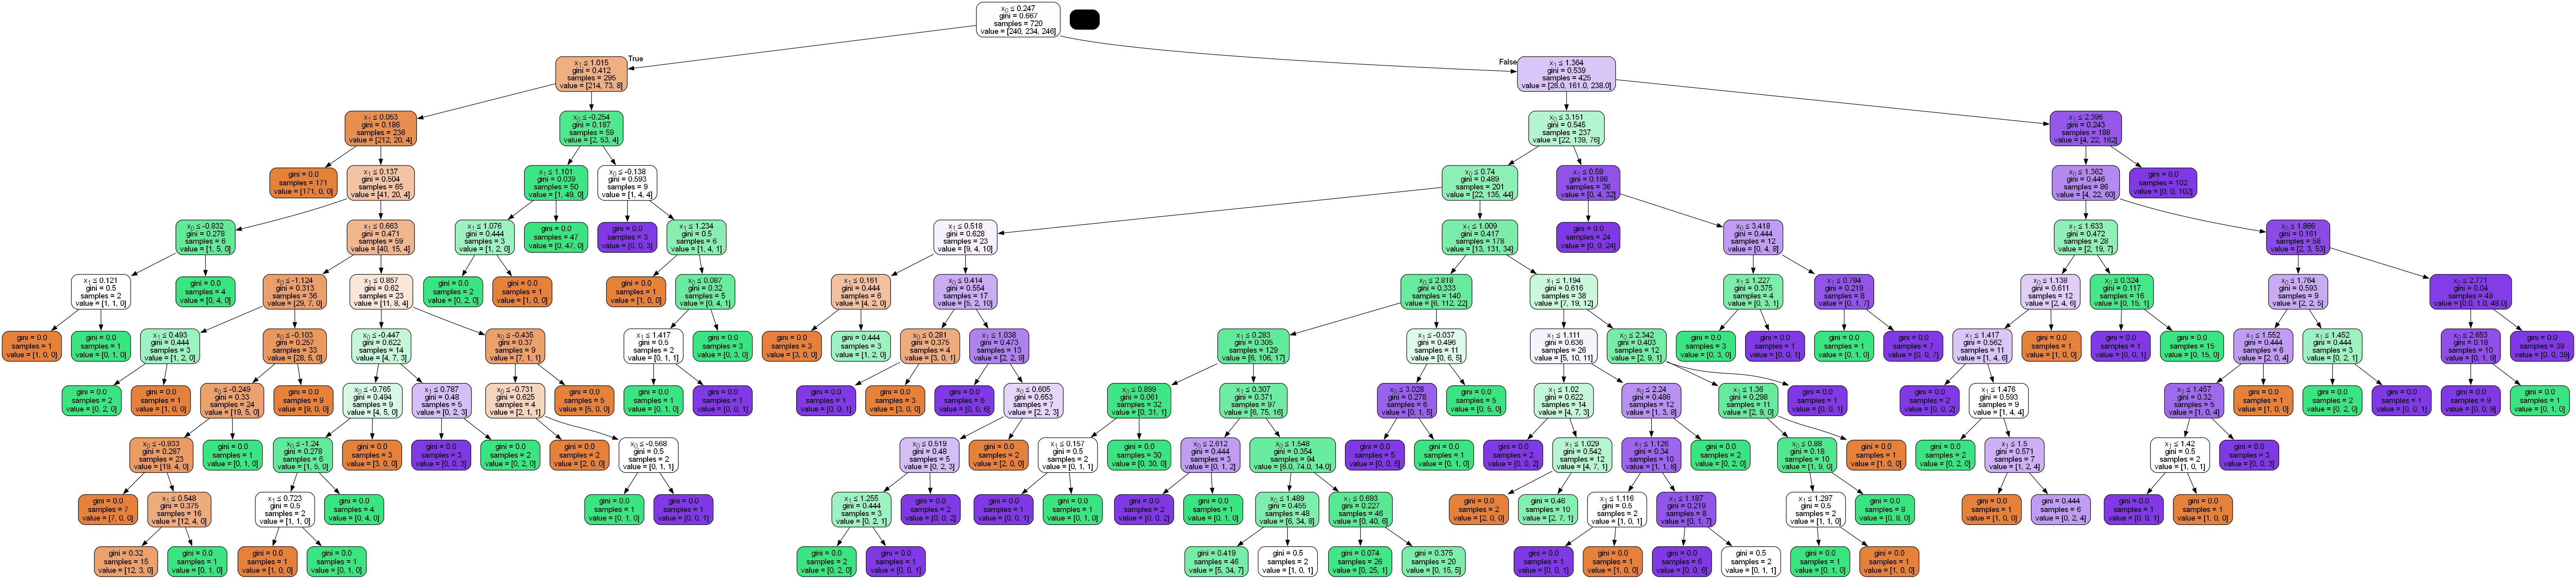

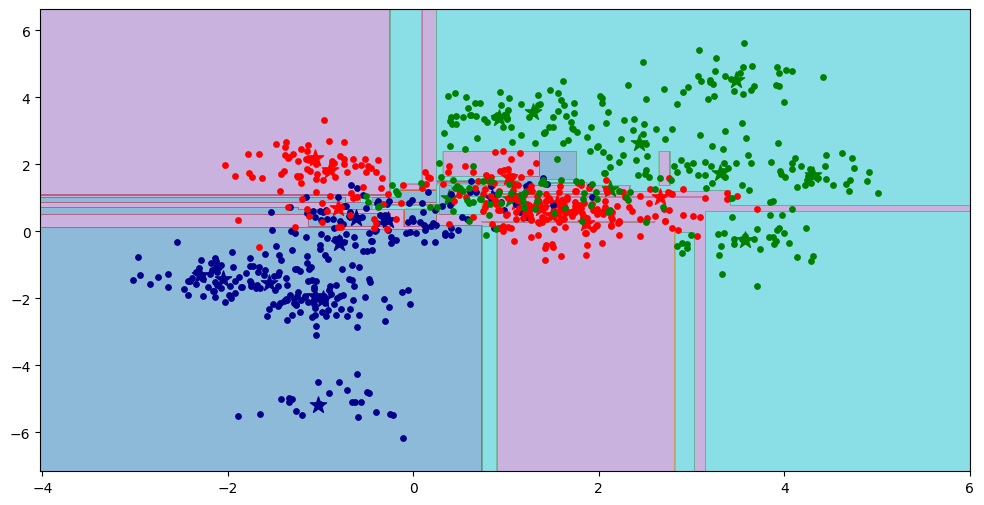

In [28]:
model = gs.best_estimator_

plot_tree(model)
plot_classifier_with_points(model, X, Y, [centers_1,centers_2, centers_3])

## Решающие деревья в регрессии

Деревья принятия решения также можно применять в регрессии.

Предсказанием для узла дерева является среднее значение (или медиана) целевой переменной. Цель минимизации - разброс в узлах. Можно считать разброс несколькими способами:

- Среднеквадратичная ошибка(MSE): $$H(D)=\frac{1}{|D|}\sum_n(y_n-\tilde{y}).$$

- Пуассоновское отклонение: $$H(D)=\frac{2}{|D|}\sum_n\left(y\ln\frac{y}{\tilde{y}}-y+\tilde{y}\right).$$

- Среднее абсолютное отклонение(MAE): $$H(D)=\frac{1}{|D|}\sum_n|y-\text{median}(y)|.$$ Заметьте, что использование MAE меняет предсказание с среднего на медиану. Она более устойчива к выбросам в данных, но время обучения возрастает в несколько раз.

In [29]:
def generate_samples(function, n_samples, x_min=0, x_max=10, sigma=1):
    """Генерирует одномерные данные с заданной зависимостью"""
    x = np.random.uniform(x_min, x_max, n_samples)
    y = function(x) + np.random.normal(0, sigma, n_samples)
    return x, y

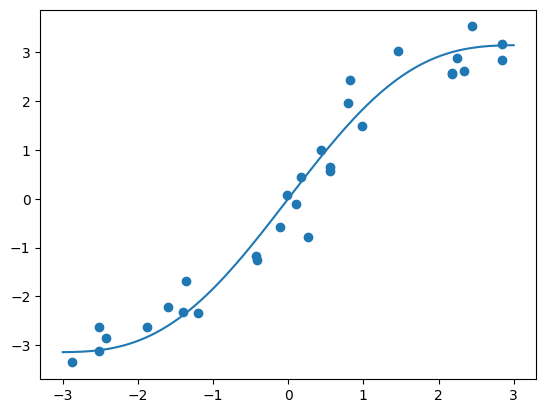

In [30]:
relation = lambda x: x + np.sin(x)
xmin, xmax = -3 , 3
xx=np.linspace(xmin, xmax, 1000)

X, Y = generate_samples(relation, 30, xmin, xmax, sigma=0.5)

plt.scatter(X,Y)
plt.plot(xx,relation(xx))

приближение наших данных с помощью кусочно постоянной функции.

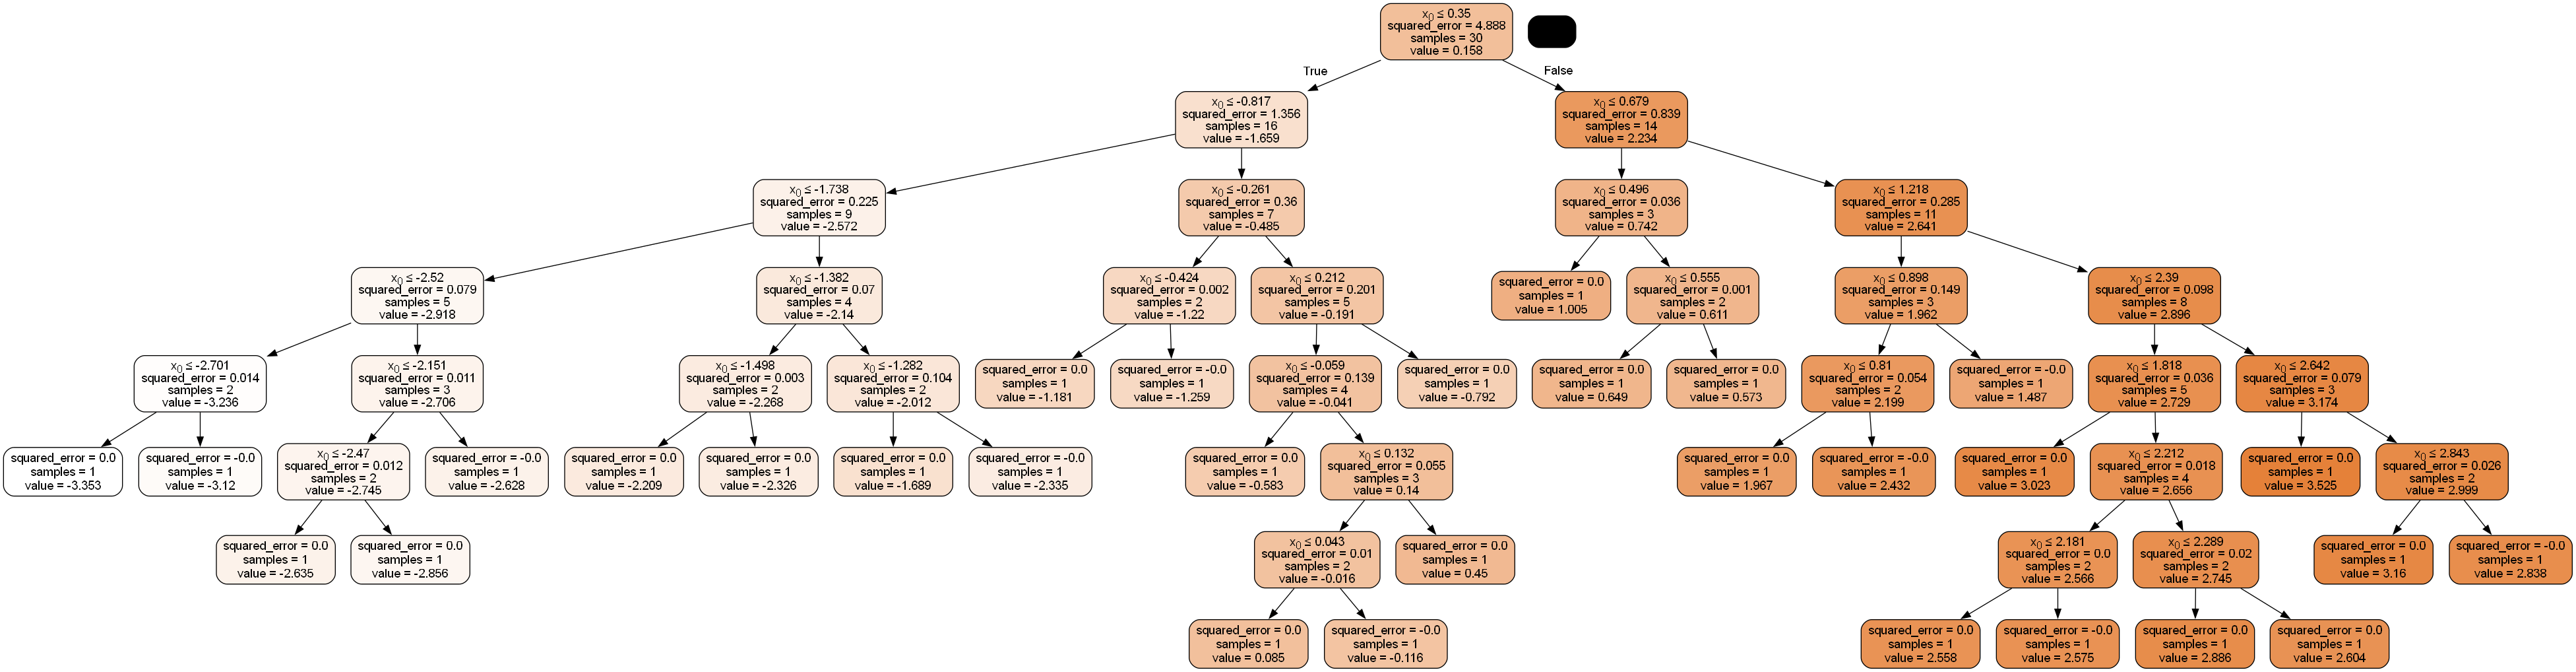

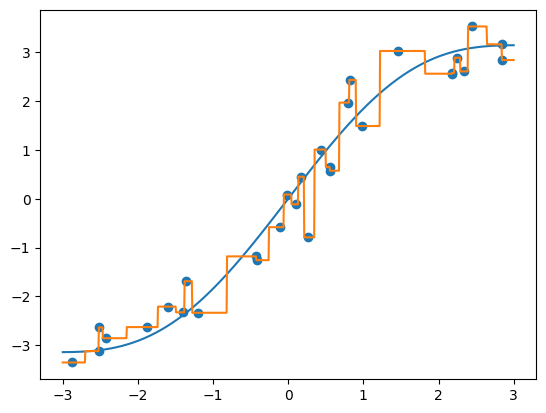

In [31]:
model = DecisionTreeRegressor()
model.fit(X[:, None], Y)

plot_tree(model)
plt.scatter(X,Y)
plt.plot(xx, relation(xx))
plt.plot(xx, model.predict(xx[:, None]))

Мы также можем применить кросс-валидацию в регрессии.

In [32]:
model = DecisionTreeRegressor()

param_dist = {
    "max_depth": randint(3, 6),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 10),
    "ccp_alpha": loguniform(1e-8, 0.1)
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=600,
                        cv=3, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X[:,None], Y)
model = rs.best_estimator_

Fitting 3 folds for each of 600 candidates, totalling 1800 fits


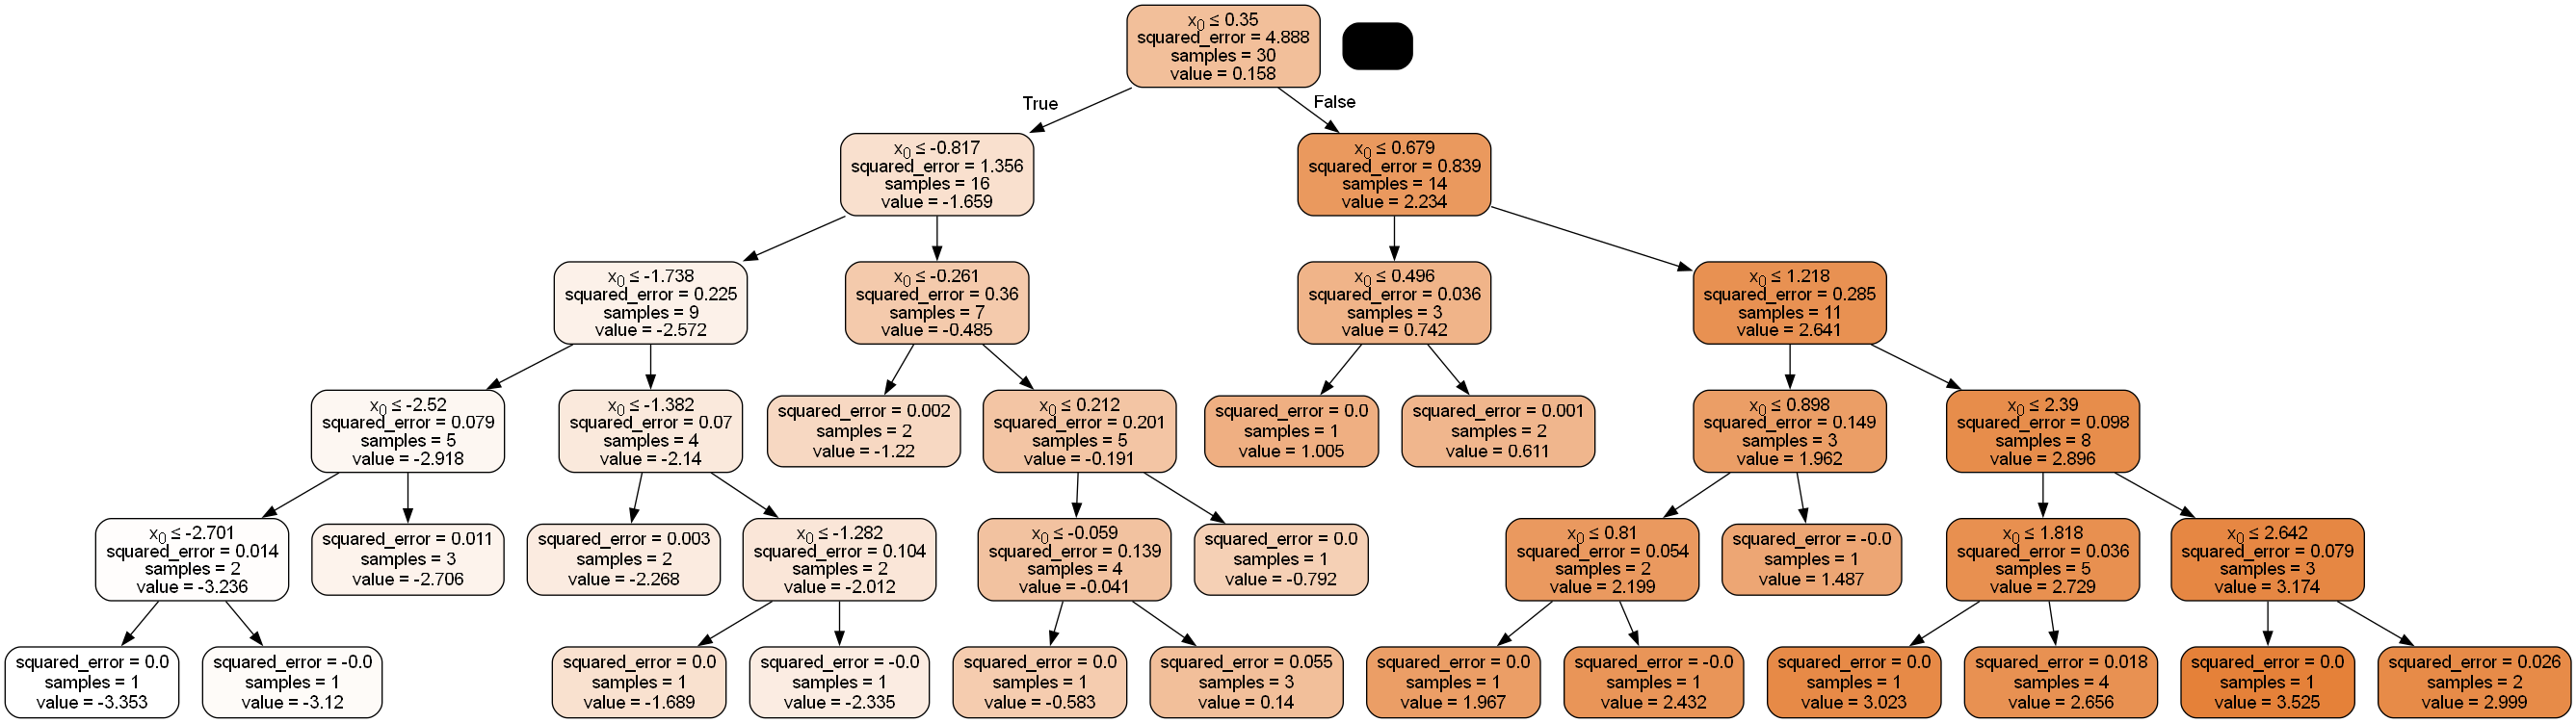

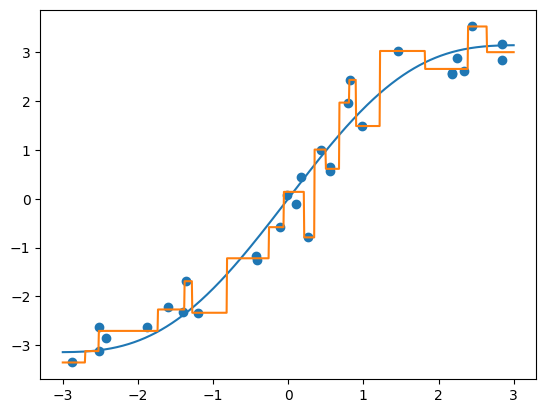

In [33]:
plot_tree(model)
plt.scatter(X,Y)
plt.plot(xx, relation(xx))
plt.plot(xx, model.predict(xx[:, None]))

In [34]:
model = DecisionTreeRegressor(criterion="absolute_error")

param_dist = {
    "max_depth": randint(3, 6),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 10),
    "ccp_alpha": loguniform(1e-8, 0.1)
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=600,
                        cv=3, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X[:,None], Y)
model = rs.best_estimator_

Fitting 3 folds for each of 600 candidates, totalling 1800 fits


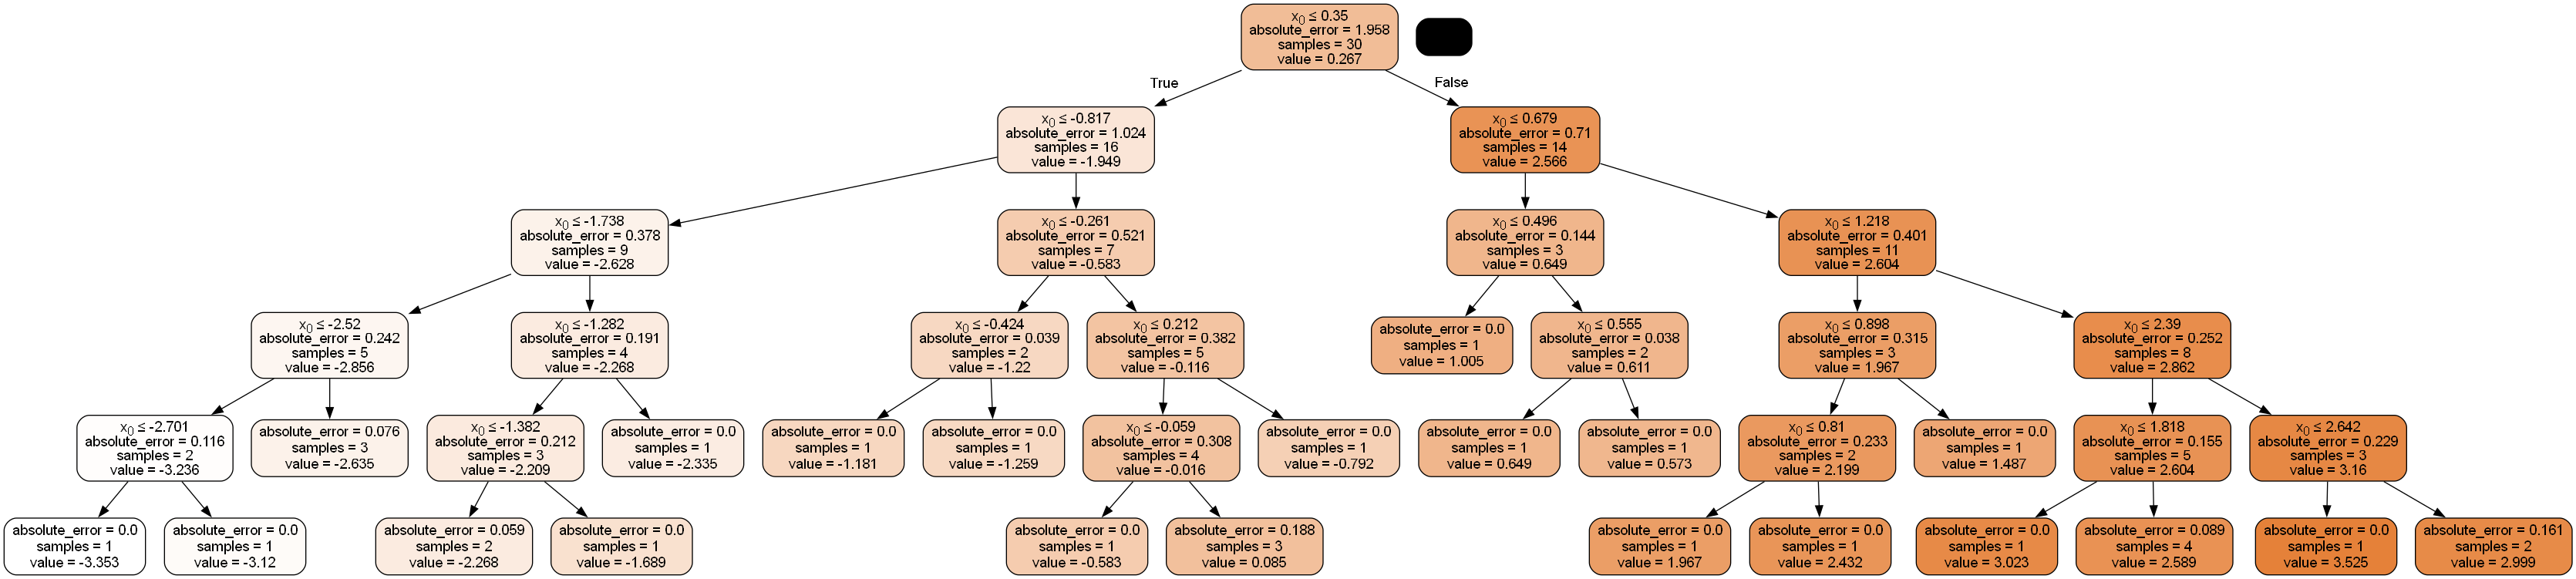

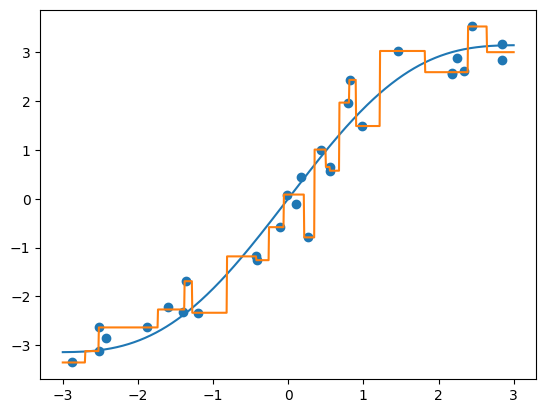

In [35]:
plot_tree(model)
plt.scatter(X,Y)
plt.plot(xx, relation(xx))
plt.plot(xx, model.predict(xx[:, None]))

## Отбор признаков с Решающими деревьями

Решающие деревья также можно применять и для отбора признаков. Чтобы оценить важность признака можно посчитать средний прирост информации (Information Gain) в каждом узле, где производилось разделение по рассматриваемому признаку. Приятно то, что это и так становится известно в процессе обучения.

Давайте протестируем этот метод на искусственных данных, а также сравним его с регрессией с L1 регуляризацией.

Метод `make_classification` из sci-kit learn позволяет нам сгенерировать данные с разным количеством информативных признаков. Сейчас мы сделаем 10 признаков. И только 3 из них будут информативными, а остальные заполнены случайно.

In [36]:
from sklearn.linear_model import LassoCV
from sklearn.datasets import make_regression


X, Y = make_regression(n_samples=1000, n_features=10, n_informative=3)

Деревья принятия решения вполне успешно могут определить значимые признаки:

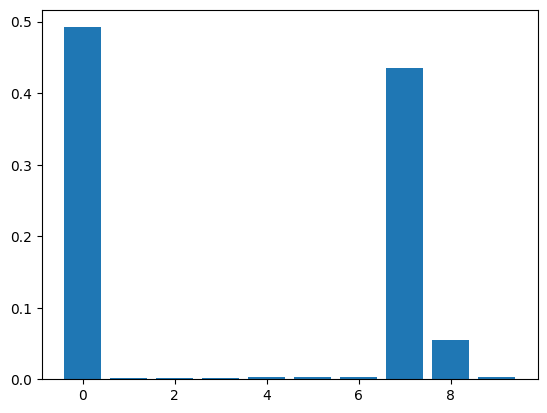

In [37]:
model = DecisionTreeRegressor()

model.fit(X,Y)

plt.bar(np.arange(X.shape[1]), model.feature_importances_) # всё уже вычислено

inform_index = np.argmax(model.feature_importances_) # сохраним индекс информативного признака

L1 регуляризация тоже справляется:

<BarContainer object of 10 artists>

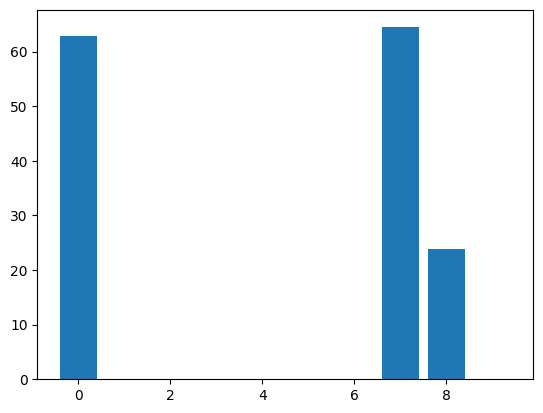

In [38]:
model = LassoCV()
model.fit(X,Y)

plt.bar(np.arange(X.shape[1]), model.coef_) 

Но давайте масштабируем признак, к примеру умножим его в 100 раз:

In [39]:
X1 = X.copy()
X1[:,inform_index] *= 100

Тут уже видна разница. В модели линейной регрессии вместе с масштабом признака поменялся и масштаб соответствующего коэффициента, после чего может показаться что этот признак тоже не важен. А решающее дерево с своей задачей справилось.

<BarContainer object of 10 artists>

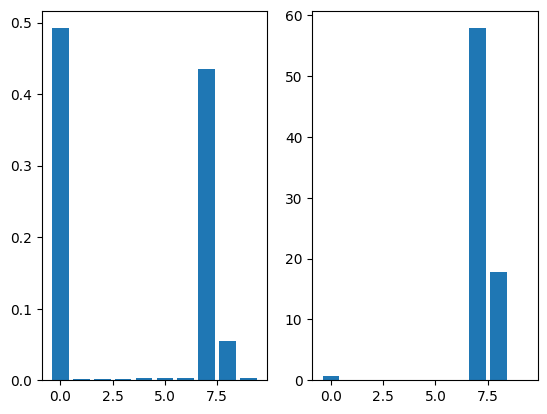

In [40]:
fig, axes = plt.subplots(1,2)

model = DecisionTreeRegressor()

model.fit(X1,Y)

axes[0].bar(np.arange(X.shape[1]), model.feature_importances_) # всё уже вычислено

model = LassoCV()
model.fit(X1,Y)

axes[1].bar(np.arange(X.shape[1]), model.coef_) 

А если сделать обратное $-$ уменьшить признак, то окажется, что L1 регуляризация снова не дала удовлетворительного результата.

<BarContainer object of 10 artists>

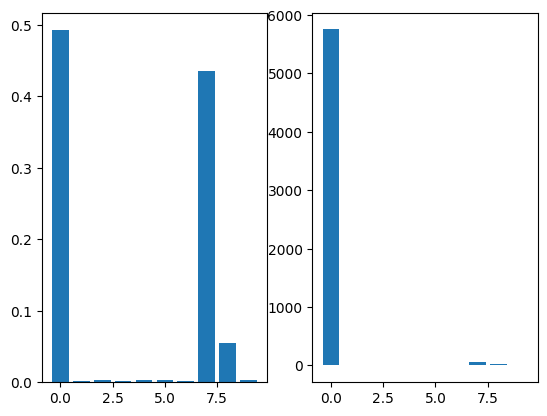

In [41]:
X1 = X.copy()
X1[:,inform_index] /= 100

fig, axes = plt.subplots(1,2)

model = DecisionTreeRegressor()

model.fit(X1,Y)

axes[0].bar(np.arange(X.shape[1]), model.feature_importances_) # всё уже вычислено

model = LassoCV()
model.fit(X1,Y)

axes[1].bar(np.arange(X.shape[1]), model.coef_) 

Тут мы увидели полезный эффект в решающих деревьях: они невосприимчивы к масштабу.

# Домашнее задание

- Загрузите набор признаков `hw2_polynomial_data.csv`. Вспомним задачу, которую мы решали во второй практике нашего курса: 

    `В этом наборе данных записаны значения функции от трёх аргументов. На функцию наложен нормальный шум. Известно, что функция имеет некоторую полиномиальную зависимость от аргументов. Найдите эту зависимость: то, какие мономы участвуют и какие перед ними коэффициенты. Результат аргументируйте.`

    Проведите отбор признаков с использованием оценки важности признаков при помощи деревьев принятия решений. 

    **Совет:** Примените кросс-валидацию для подбора оптимальных параметров модели. Важность признаков оценивайте по модели с наилучшим качеством.

- Отобразите полученное дерево решения. Прокомментируйте как полученные гиперпараметры повлияли на полученное дерево.

In [42]:
df = pd.read_csv('hw2_polynomial_data.csv')
X = df.drop(columns=["y", "Unnamed: 0"])
Y = df["y"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [51]:
# 1
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

degree = 3
# model = DecisionTreeRegressor(random_state=42)

# param_dist = {
#     "max_depth": randint(3, 60),
#     "min_samples_split": randint(2, 50),
#     "min_samples_leaf": randint(1, 30),
#     "ccp_alpha": loguniform(1e-9, 0.1)
# }

# rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=6000,
#                         cv=5, scoring="r2", n_jobs=-1, random_state=42, verbose=1)

# rs.fit(X_train, Y_train)

# model = DecisionTreeRegressor(ccp_alpha=params['ccp_alpha'], max_depth=params['max_depth'], min_samples_leaf=params['min_samples_leaf'], min_samples_split=params['min_samples_split'])
# model.fit()

pipeline = Pipeline([
    ('polynom', PolynomialFeatures(degree=degree, include_bias=False)),
    ('tree', DecisionTreeRegressor(random_state=42))
])

pipeline.fit(X_train, Y_train)

param_dist = {
    "tree__max_depth": randint(3, 30),
    "tree__min_samples_split": randint(2, 30),
    "tree__min_samples_leaf": randint(1, 20),
    "tree__ccp_alpha": loguniform(1e-6, 0.1)
}

rs = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=6000,
                        cv=5, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train, Y_train)

Fitting 5 folds for each of 6000 candidates, totalling 30000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'tree__ccp_alpha': <scipy.stats....001FF183DE470>, 'tree__max_depth': <scipy.stats....001FF1F24DB20>, 'tree__min_samples_leaf': <scipy.stats....001FF1879BB10>, 'tree__min_samples_split': <scipy.stats....001FF187AC7D0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer

In [59]:
print("Лучшие параметры:", rs.best_params_)
print("Лучший R² (CV):", rs.best_score_)

best_pipeline = rs.best_estimator_

# Достаём PolynomialFeatures из пайплайна
poly_step = best_pipeline.named_steps['polynom']
# Достаём дерево
tree_step = best_pipeline.named_steps['tree']

# Имена полиномиальных признаков (например, x0, x1, x2, x0^2, x0*x1, ...)
feature_names = poly_step.get_feature_names_out(input_features=X.columns)
importances = tree_step.feature_importances_

# Сортировка по важности
indices = np.argsort(importances)[::-1]
for i in indices[:15]:   # топ-15
    print(f"{feature_names[i]}: {importances[i]:.4f}")

# params = rs.best_params_
# r2 = rs.best_score_

# print(f"Лучшие параметры: {params}")
# print(f"Лучший R2: {r2}")
# print(f"Отбор признаков: {rs.best_estimator_.feature_importances_}")

Лучшие параметры: {'tree__ccp_alpha': np.float64(0.014622818045025285), 'tree__max_depth': 9, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Лучший R² (CV): 0.5691611073056138
x0 x1 x2: 0.8720
x0 x2^2: 0.0626
x0^2 x1: 0.0246
x0^2 x2: 0.0121
x0^2: 0.0119
x1^2 x2: 0.0052
x1^2: 0.0037
x0 x2: 0.0023
x0 x1: 0.0017
x1: 0.0013
x2^2: 0.0010
x0 x1^2: 0.0008
x1 x2: 0.0006
x0^3: 0.0001
x2^3: 0.0000


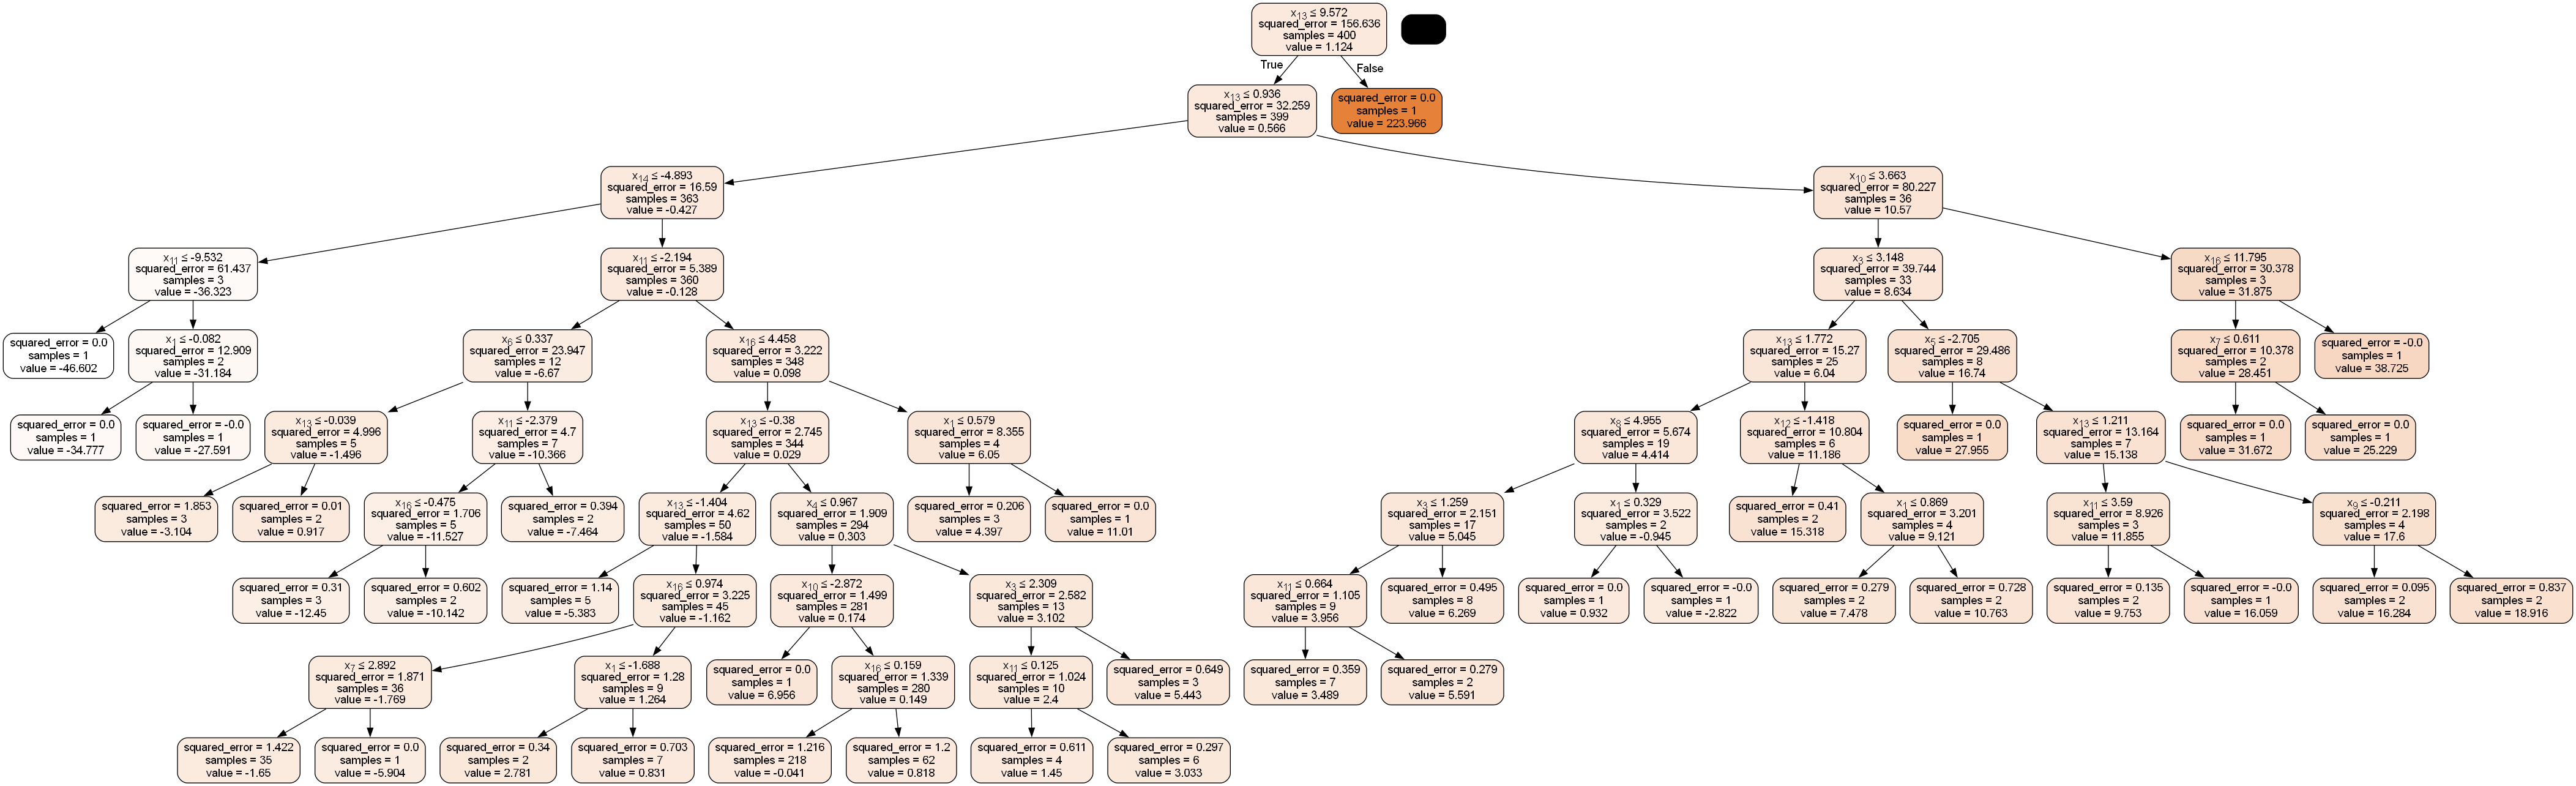

In [60]:
# 2

best_tree = rs.best_estimator_
tree = best_pipeline.named_steps['tree']
plot_tree(tree)